 ## Quantum 
 ### 3 superconducting Qubits  (Transmon) 

In [1203]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")


In [1204]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities(statevector):
    probabilities = statevector.probabilities()
    num_qubits = int(np.log2(len(probabilities)))
    basis_states = [f"|{i:0{num_qubits}b}⟩" for i in range(2**num_qubits)]
    
    plt.figure(figsize=(10, 5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel('Computational basis states')
    plt.ylabel('Probability')
    # plt.title('Measurement Probabilities of Statevector')
    plt.ylim(0, 0.8)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [1205]:
backend  = FakeSherbrooke()

propiedades   = backend.properties()
configuracion = backend.configuration()

Hz = 1e9
# frecuencia de los qubits en GHz
w7     = configuracion.hamiltonian.get("vars").get("wq7")
w8     = configuracion.hamiltonian.get("vars").get("wq8")

# anarmonicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")

# acoples en GHz
J78    = configuracion.hamiltonian.get("vars").get("jq7q8")

# fuerza de control de GHz 
r0     = configuracion.hamiltonian.get("vars").get("omegad7")
r1     = configuracion.hamiltonian.get("vars").get("omegad8") 

# tiempo de gate en ns 
dt     = backend.dt*1e9

In [1206]:
propiedades.qubit_property(7,name='frequency')

(4755587722.216813,
 datetime.datetime(2025, 2, 26, 14, 43, 10, tzinfo=tzoffset(None, -18000)))

In [1150]:
# tiempo de relajación y decoherencia en segundos
T1_7     = propiedades.qubit_property(7,'T1')[0]  # tiempo de relajación
T2_7     = propiedades.qubit_property(7,'T2')[0]  # tiempo de decoherencia
T1_8     = propiedades.qubit_property(8,'T1')[0]  # tiempo de relajación
T2_8     = propiedades.qubit_property(8,'T2')[0]  # tiempo de decoherencia


# Tiempos T1 y T2 en ns
T1_7 = T1_7*1e9
T2_7 = T2_7*1e9
T1_8 = T1_8*1e9
T2_8 = T2_8*1e9
# gammas de relajación y decoherencia
gamma1_7 = 1/T1_7
gamma2_7 = 1/T2_7 - 1/(2*T1_7)
gamma1_8 = 1/T1_8
gamma2_8 = 1/T2_8 - 1/(2*T1_8)

In [1151]:
print(T1_8,T2_8)

394165.10585714877 17282.471331162924


In [1152]:
v7     = w7/(2*np.pi) # frecuencia en GHz
v8     = w8/(2*np.pi)  # frecuencia en GHz
# v9     = w9/(2*np.pi)  # frecuencia en GHz  

# estado inicial 
rho_0  = DensityMatrix.from_label("00")

y0 = Statevector.from_label("00")

In [1153]:
propiedades.qubit_property(7,name='frequency')

(4755587722.216813,
 datetime.datetime(2025, 2, 26, 14, 43, 10, tzinfo=tzoffset(None, -18000)))

In [1154]:
# Definir los operadores 
# dimensión del espacio de Hilbert de cada qubit 
dim        = 2
# operadores de creación, aniquilación y número 
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident      = np.eye(dim, dtype=complex)
full_indet = np.eye(dim**2, dtype=complex)
# operador número y creación/aniquilación para cada qubit en el sistema de dos qubits
N0         = np.kron(ident,N)
N1         = np.kron(N,ident)

# operador de creación 
a0         = np.kron(ident,a)
a1         = np.kron(a,ident)
# operador de aniquilación
a0dag      = np.kron(ident,adag)
a1dag      = np.kron(adag,ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  + 2*np.pi*v8 * N1   + J78*(a0dag @ a1 +  a0 @ a1dag) 

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)


Z0  = full_indet - 2*N0
Z1  = full_indet - 2*N1

sm1 = a0
sm2 = a1

sz1 = Z0
sz2 = Z1 

collapse_operators = [np.sqrt(gamma1_7)*a0,
                      np.sqrt(gamma1_8)*a1,
                      np.sqrt(gamma2_7)*Z0,
                      np.sqrt(gamma2_8)*Z1]



In [1155]:
print(w7, "  ","  ",w8)

29.88023890323631       30.23802708662245


In [1156]:
print(J78)

0.012651918734551187


In [1157]:
print(r0, "  ", r1)

0.39575797919595557    0.6501466069370565


In [1158]:
2*np.pi*r0

2.4866207200831125

In [1159]:
0.22*2*np.pi

1.382300767579509

In [1160]:
solver_closed = Solver(
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7, H_drive8, H_drive7],
    hamiltonian_channels=["d0", "d1", "u0"],
    channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8},
    dt=dt,
    array_library="jax",
)

## Dynamics solution

In [1161]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1 ,A0, A1, A2 = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)

   
    

    with pulse.build(name="Bell pulse") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
        
    
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)       
      
        
    return kp
   

In [1162]:
def objective_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_closed.solve(
        t_span=[0, tiempo_t*dt],
        y0= y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-8,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

In [1163]:

# m =  [
#         103.05123780863588,
#         986.0824006034504,
#         0.0,
#         0.0,
#         0.5921082751744258,
#         0.6616092971358292,
#         0.5466298527554176,
#         0.0,
#         0.0,
#     ]

# mm = [1.02352757e+02, 9.72567276e+02, 0.00000000e+00, 0.00000000e+00,
#  5.96232363e-01, 6.52140599e-01,  5.22337036e-01,
#  0.00000000e+00, 0.00000000e+00]


mmm = [ 1.91910934e+02,
       7.97242687e+02, 
       0.00000000e+00,
       0.00000000e+00,
      -3.05971089e-01,
       8.64530800e-01,
      -7.93432089e-01,
       0.00000000e+00,
       0.00000000e+00,
      ]


mmmm=   [ 1.91910934e+02,  
         7.97242687e+02,  
         1.64068678e+02,
         1.68760003e+03,
        -3.05971089e-01,
        8.64530800e-01,
        -7.93432089e-01,
        8.83994697e-01,
       -8.36539122e-01,
       ]





parametros_optimos =  [
        202.9295423047658,
        1258.1648854894204,
        192.1238241246524,
        1860.2496455494108,
        0.4302391752867789,
        -0.05416696911702623,
        0.45105849258854414,
        0.5052878150042629,
        -0.48319328703627806,
       ]

x =  [ 2.02977227e+02,  1.24590825e+03,  1.92893062e+02,  1.85898891e+03,
  4.30640491e-01, -5.69626179e-02,  4.51052541e-01,  5.10797206e-01,
 -4.79180337e-01]


f =  [ 2.02977227e+02,  1.24590825e+03,  0,  0,
  4.30640491e-01, -5.69626179e-02,  4.51052541e-01,  0,
 0]


parametros_optimos_2 = [
        191.910934,
        797.242687,
        0.6824432988764655,
        0.8286644926788276,
        0.7868326972398657,
    ]

x0 = [
        202.9295423047658,
        1258.1648854894204,
        0.4302391752867789,
        -0.05416696911702623,
        0.45105849258854414,
        ]

w =  [ 2.67361243e+02,  8.33596515e+02
 -9.22902096e-02, -8.79264770e-02, -8.79093211e-01, ]


# parametros_optimos_2 = [
#         191.910934,
#         0.6824432988764655,
#         0.8286644926788276,]

parametros_optimos_2 = [
        191.910934,
        797.242687,
        0.6824432988764655,
        0.8286644926788276,
        0.7868326972398657,
    ]


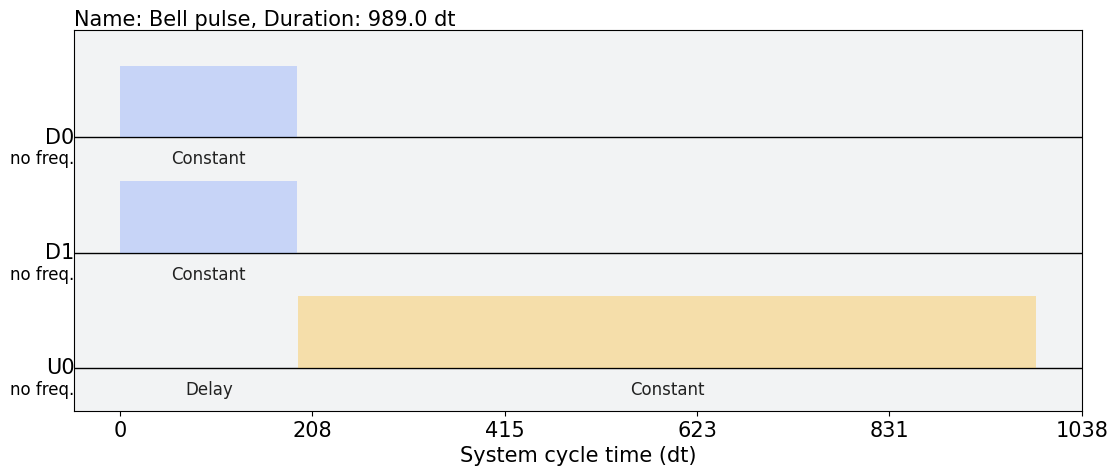

In [1164]:
esque_pul(parametros_optimos_2).draw()

In [1165]:
objective_12(parametros_optimos_2).draw("latex")

<IPython.core.display.Latex object>

In [1166]:
negativity(objective_12(parametros_optimos_2),[0])
# (concurrence(partial_trace(objective_12(tt),[0]))**2 + concurrence(partial_trace(objective_12(tt),[1]))**2 + concurrence(partial_trace(objective_12(tt),[2]))**2)/3


np.float64(0.49984039469001074)

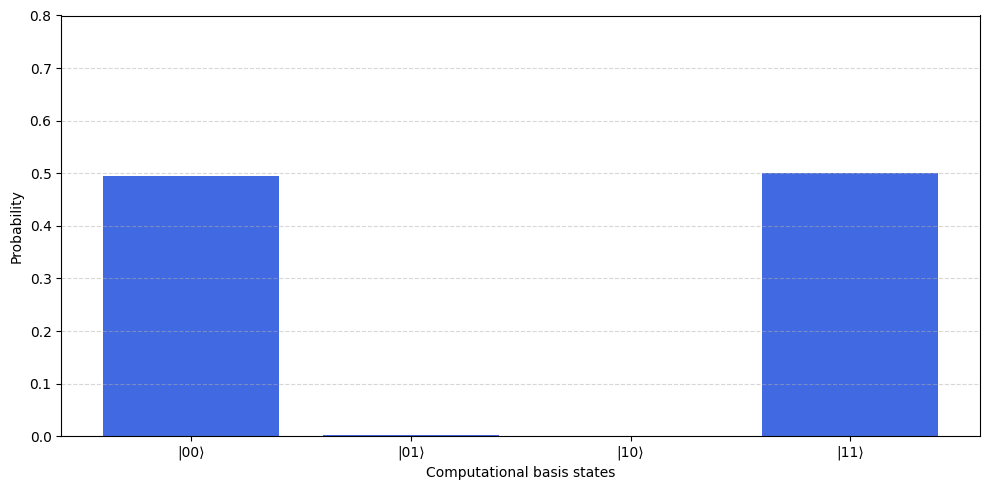

In [1167]:
plot_statevector_probabilities(objective_12(parametros_optimos_2))

In [1168]:
def evol_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_closed.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        atol=1e-10,
        rtol=1e-8
    )
   
    return sol

In [1169]:
evol = evol_12(parametros_optimos_2)

In [1170]:
nega_closed = []
for i in range(len(evol.t)):
    nega_closed.append(negativity(evol.y[i],[1]))

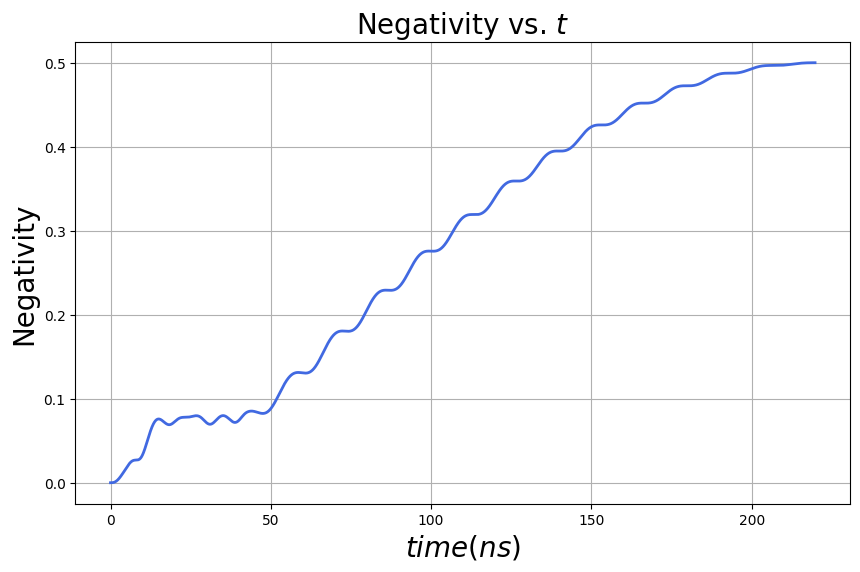

In [1171]:
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(evol.t,  nega_closed, color = 'royalblue', linewidth = 2, label = 'Negativity')
# plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Negativity vs. $t$', fontsize = fontsize)
ax.grid()

In [1172]:
solver_open =  solver = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators= [H_drive7, H_drive8, H_drive7],
                static_dissipators = collapse_operators,
                dissipator_channels= None,
                hamiltonian_channels=['d0', 'd1', 'u0'],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8 },
                dt=dt,
                array_library='jax'
                )

In [1173]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1 ,A0, A1, A2  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
  
    with pulse.build(name="pulso 2q") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
    

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)   
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)
        # delay pulso d2 y u1        
    return kp

# %%
parametros_optimos = [
          332.62472447863985,
          680.4137630830777,
          0.6173140947022615,
          0.6487042324680496,
          0.9208267387996893
     ]
# parametros_optimos = [
#           0.0,
#           680.4137630830777,
#           0.0,
#           0.0,
#           0.9208267387996893
#      ]

In [1174]:
def sanitize_density_matrix(rho):
    """
    Corrige una matriz para que sea una matriz densidad física:
    - Hermítica
    - Traza 1
    - Semidefinida positiva
    """
    rho = np.array(rho, dtype=complex)

    # 1) Forzar hermiticidad
    rho = 0.5 * (rho + rho.conj().T)

    # 2) Diagonalizar
    eigvals, eigvecs = np.linalg.eigh(rho)

    # 3) Eliminar negativos pequeños
    eigvals[eigvals < 0] = 0

    # 4) Reconstruir
    rho = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # 5) Renormalizar traza
    rho = rho / np.trace(rho)

    return DensityMatrix(rho)

In [1175]:
def objective_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        method="jax_odeint",
        atol=1e-11,
        rtol=1e-11
    )
    yf = sol.y[-1]
    density_matrix = sanitize_density_matrix(yf)
    cost = (0.5 - negativity(density_matrix,[0]))**2
    return cost

In [1176]:
def estado_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]
    density_matrix = sanitize_density_matrix(yf)
    
    return density_matrix


def evol_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    
    return sol

In [1177]:
solu = estado_bell_lindblab(parametros_optimos)

In [1178]:
evol_open = evol_bell_lindblab(parametros_optimos)

In [1180]:
sanitize_density_matrix(evol_open.y[-1])

DensityMatrix([[ 0.32601665-4.52438991e-18j, -0.22710342-1.22329341e-01j,
                -0.01876268-2.51011813e-01j,  0.12199082-2.56065029e-01j],
               [-0.22710342+1.22329341e-01j,  0.21327922+1.09179440e-17j,
                 0.10847899+1.71668889e-01j,  0.01330464+2.28212310e-01j],
               [-0.01876268+2.51011813e-01j,  0.10847899-1.71668889e-01j,
                 0.20242294-2.80918256e-18j,  0.19583096+1.08794298e-01j],
               [ 0.12199082+2.56065029e-01j,  0.01330464-2.28212310e-01j,
                 0.19583096-1.08794298e-01j,  0.25828119-3.58437157e-18j]],
              dims=(2, 2))


In [1181]:
Density_matrix = []
for i in range(len(evol_open.y)):
    Density_matrix.append(sanitize_density_matrix(evol_open.y[i]))

In [1182]:
nega_open = []
for i in range(len(Density_matrix)):
    nega_open.append(negativity(Density_matrix[i], [1]))

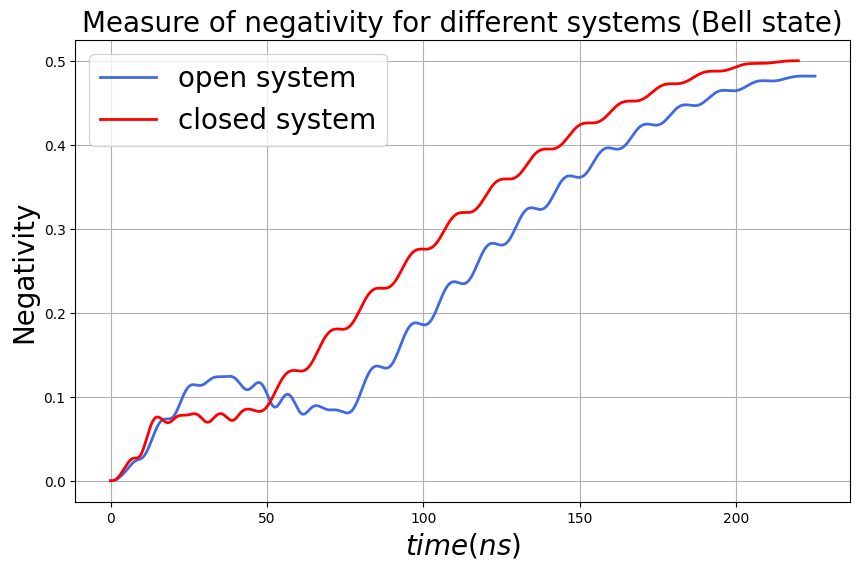

In [1183]:
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(evol_open.t,  nega_open, color = 'royalblue', linewidth = 2, label = 'open system')
plt.plot(evol.t,  nega_closed, color = 'red', linewidth = 2, label = 'closed system')
plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Measure of negativity for different systems (Bell state)', fontsize = fontsize)
ax.grid()

## Parte De comparar

In [1109]:
solver_open =  solver = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators= [ H_drive7],
                static_dissipators = collapse_operators,
                dissipator_channels= None,
                hamiltonian_channels=['u0'],
                channel_carrier_freqs= {"u0": v8 },
                dt=dt,
                array_library='jax'
                )

In [1110]:
from qiskit import pulse

def esque_pul(params):
    t_1, A2 = params

    # Convertir a enteros por requerimiento del backend
    # t_0 = int(t_0)
    t_1 = int(t_1)

   
    

    with pulse.build(name="Bell pulse") as kp:
        # d0 = pulse.DriveChannel(0)
        # d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        

        # Primer pulso en d0 y d1
        # pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        # pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
        
    
        # Delay en canal u0
        # pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)       
      
        
    return kp

In [1112]:
def evol_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    
    return sol

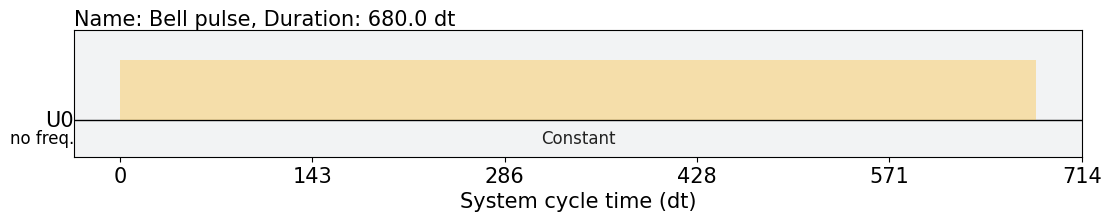

In [1113]:
esque_pul(parametros_optimos).draw()

In [1114]:
parametros_optimos = [680.4137630830777,0.9208267387996893]

In [1115]:
evol_open = evol_bell_lindblab(parametros_optimos)

In [1120]:
list_ta  = []
list_ya = []
for i in range(len(evol_open.t)):
    list_ta.append(evol_open.t[i])
    list_ya.append(nega_open[i])
    
# list_t  = []
# list_y = []
# for i in range(len(evol_open.t)):
#     list_t.append(evol_open.t[i])
#     list_y.append(nega_open[i])

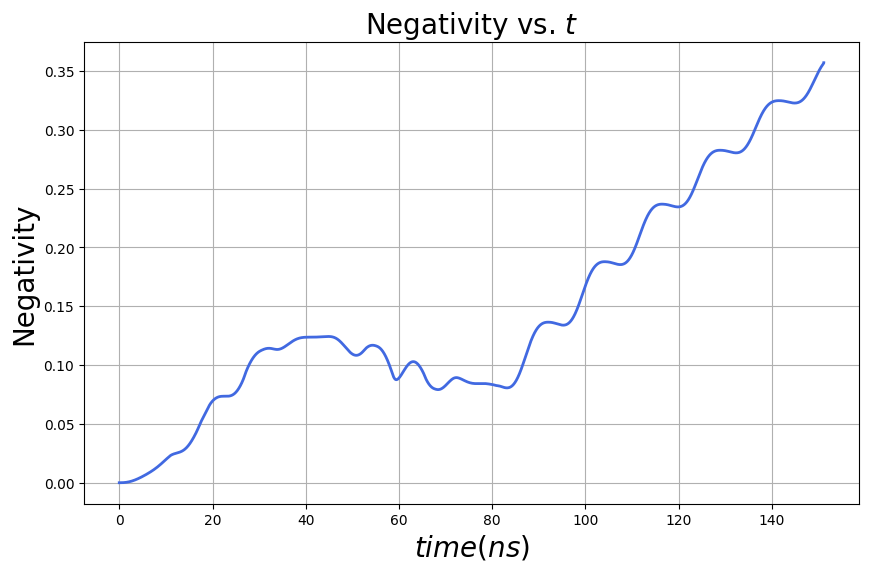

In [1121]:
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(list_ta,  list_ya, color = 'royalblue', linewidth = 2, label = 'Negativity')
# plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Negativity vs. $t$', fontsize = fontsize)
ax.grid()

In [771]:
np.array(list_t)

array([106.0653765 , 106.08476221, 106.10411868, ..., 148.96281965,
       148.97904316, 148.99526774], shape=(2439,))


ESTIMACIONES INICIALES
a0      = -2.9069221814e-03
b0      = 1.9781872601e-03

Componente 1:
A01     = 2.3789269956e-02
omega01 = 4.1574510484e-02
f01     = 6.6167888502e-03

Componente 2:
A02     = 2.3789269956e-02
omega02 = 1.2472353145e-01
f02     = 1.9850366550e-02

Componente 3:
A03     = 2.3789269956e-02
omega03 = 4.9889412581e-01
f03     = 7.9401466202e-02

PARÁMETROS DEL AJUSTE
a      = -1.3626547951e-02
b      = 2.0273362881e-03

Componente 1:
A1     = 5.3829201728e-02
omega1 = 5.5211599083e-02
phi1   = -1.6050203187e+00

Componente 2:
A2     = 1.2472122709e-02
omega2 = 1.0582509015e-01
phi2   = 1.6377290291e+00

Componente 3:
A3     = 6.7591658893e-03
omega3 = 5.1639793656e-01
phi3   = -2.7754109900e+00

VARIANZAS Y ERRORES

a
Valor          = -1.3626547951e-02
Varianza       = 7.0451565785e-08
Error estándar = 2.6542713837e-04
Valor ± error  = -1.3626547951e-02 ± 2.6542713837e-04

b
Valor          = 2.0273362881e-03
Varianza       = 1.8908070005e-11
Error estándar = 4.34834

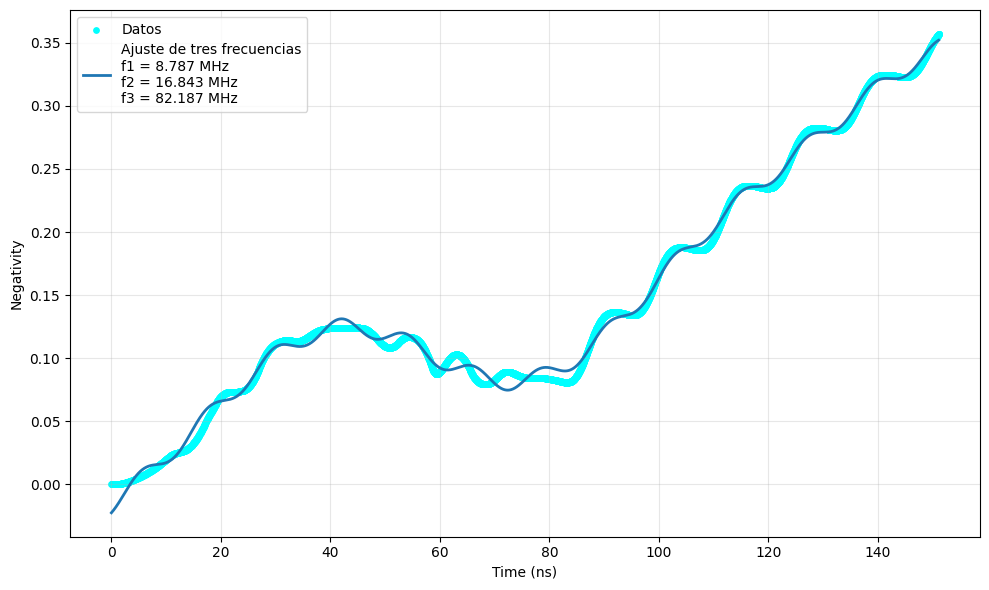

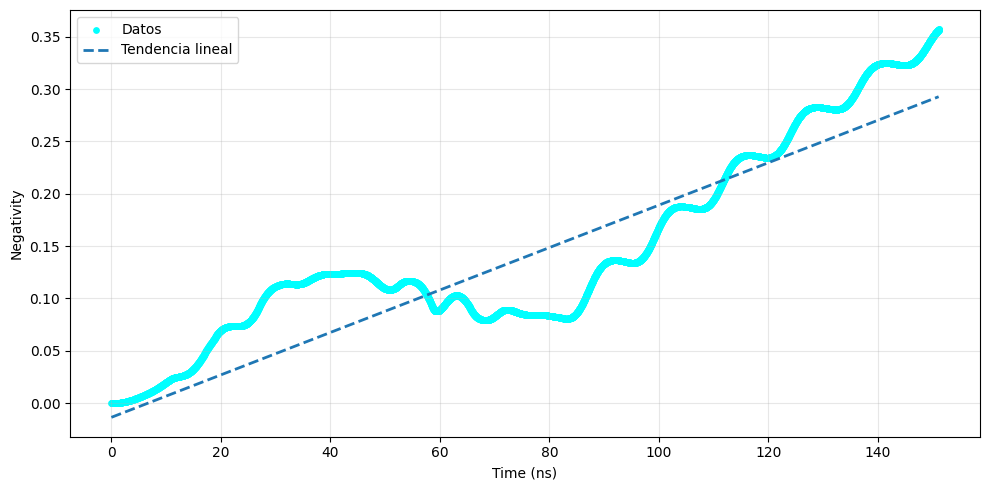

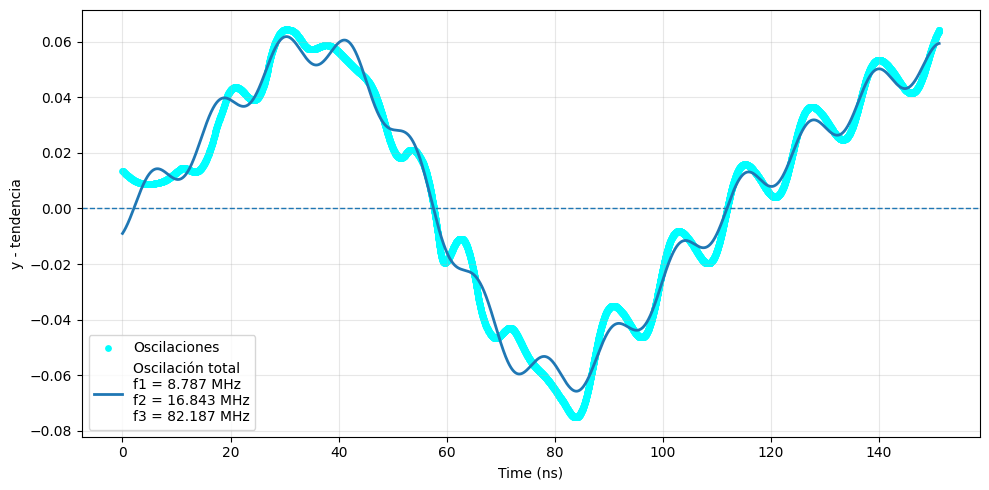

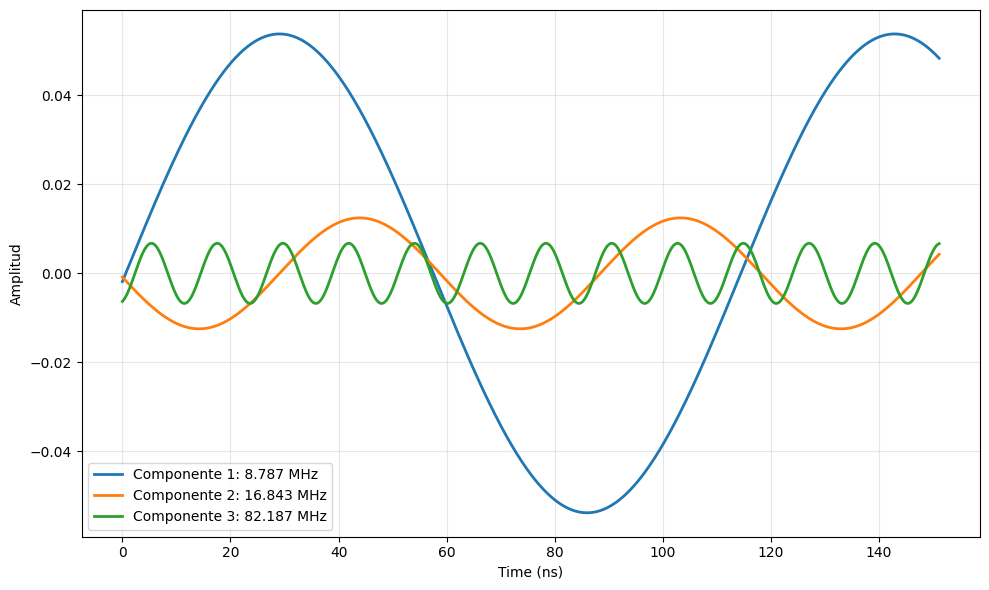



################################################
#              RESULTADO FINAL                 #
################################################

Modelo:
y(t) = a + b*t + A1*cos(w1*t + phi1) + A2*cos(w2*t + phi2) + A3*cos(w3*t + phi3)

Parámetros:
a = -1.36265480e-02 ± 2.65e-04
b = 2.02733629e-03 ± 4.35e-06

Componente 1:
A1 = 5.38292017e-02 ± 8.89e-05
omega1 = 5.52115991e-02 ± 1.58e-04 rad/ns
phi1 = -1.60502032e+00 ± 9.79e-03
f1 = 8.78719891 ± 0.02511376 MHz
T1 = 113.80190778 ± 0.32524511 ns

Componente 2:
A2 = 1.24721227e-02 ± 1.34e-04
omega2 = 1.05825090e-01 ± 4.14e-04 rad/ns
phi2 = 1.63772903e+00 ± 2.70e-02
f2 = 16.84258620 ± 0.06587456 MHz
T2 = 59.37330455 ± 0.23222028 ns

Componente 3:
A3 = 6.75916589e-03 ± 8.84e-05
omega3 = 5.16397937e-01 ± 3.13e-04 rad/ns
phi3 = -2.77541099e+00 ± 2.77e-02
f3 = 82.18728421 ± 0.04977335 MHz
T3 = 12.16733233 ± 0.00736864 ns

-----------------------------------------------
CALIDAD DEL AJUSTE
-----------------------------------------------
R²   

In [1184]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# DATOS
# ============================================================

x = np.asarray(list_ta, dtype=float)
y = np.asarray(list_ya, dtype=float)

# Eliminar NaN e infinitos
mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]

# Ordenar por tiempo
idx = np.argsort(x)

x = x[idx]
y = y[idx]


# ============================================================
# MODELO
#
# y(t) = a + b*t
#      + A1*cos(w1*t + phi1)
#      + A2*cos(w2*t + phi2)
#      + A3*cos(w3*t + phi3)
# ============================================================

def modelo(
    x,
    a,
    b,
    A1, omega1, phi1,
    A2, omega2, phi2,
    A3, omega3, phi3
):

    return (
        a
        + b*x

        + A1*np.cos(
            omega1*x + phi1
        )

        + A2*np.cos(
            omega2*x + phi2
        )

        + A3*np.cos(
            omega3*x + phi3
        )
    )


# ============================================================
# ESTIMACIONES INICIALES
# ============================================================

# ------------------------------------------------------------
# Tendencia lineal
# ------------------------------------------------------------

b0, a0 = np.polyfit(x, y, 1)

# Eliminar tendencia
y_detrend = y - (a0 + b0*x)


# ------------------------------------------------------------
# FFT
# ------------------------------------------------------------

dt = np.mean(np.diff(x))

frecuencias = np.fft.rfftfreq(
    len(x),
    d=dt
)

fft_y = np.abs(
    np.fft.rfft(y_detrend)
)


# Ignorar frecuencia cero
fft_y[0] = 0


# ------------------------------------------------------------
# Buscar los 3 picos principales
# ------------------------------------------------------------

indices_ordenados = np.argsort(
    fft_y
)[::-1]


indices_picos = []

for indice in indices_ordenados:

    # Evitar frecuencias demasiado cercanas
    if all(
        abs(
            frecuencias[indice]
            - frecuencias[j]
        )
        > 1.0 / (
            x.max() - x.min()
        )
        for j in indices_picos
    ):

        indices_picos.append(indice)

    if len(indices_picos) == 3:
        break


# Ordenar las frecuencias
indices_picos = sorted(
    indices_picos,
    key=lambda i: frecuencias[i]
)


# ------------------------------------------------------------
# Frecuencias iniciales
# ------------------------------------------------------------

f01 = frecuencias[indices_picos[0]]
f02 = frecuencias[indices_picos[1]]
f03 = frecuencias[indices_picos[2]]


# Frecuencias angulares iniciales
omega01 = 2*np.pi*f01
omega02 = 2*np.pi*f02
omega03 = 2*np.pi*f03


# ------------------------------------------------------------
# Amplitudes iniciales
# ------------------------------------------------------------

A01 = (
    np.max(y_detrend)
    - np.min(y_detrend)
) / 6

A02 = A01
A03 = A01


# Fases iniciales
phi01 = 0
phi02 = 0
phi03 = 0


# ============================================================
# VECTOR INICIAL
# ============================================================

p0 = [

    a0,
    b0,

    A01,
    omega01,
    phi01,

    A02,
    omega02,
    phi02,

    A03,
    omega03,
    phi03
]


# ============================================================
# ESTIMACIONES INICIALES
# ============================================================

print("\n==============================================")
print("ESTIMACIONES INICIALES")
print("==============================================")

print(f"a0      = {a0:.10e}")
print(f"b0      = {b0:.10e}")

print("\nComponente 1:")
print(f"A01     = {A01:.10e}")
print(f"omega01 = {omega01:.10e}")
print(f"f01     = {f01:.10e}")

print("\nComponente 2:")
print(f"A02     = {A02:.10e}")
print(f"omega02 = {omega02:.10e}")
print(f"f02     = {f02:.10e}")

print("\nComponente 3:")
print(f"A03     = {A03:.10e}")
print(f"omega03 = {omega03:.10e}")
print(f"f03     = {f03:.10e}")


# ============================================================
# AJUSTE NO LINEAL
# ============================================================

parametros, covarianza = curve_fit(

    modelo,

    x,
    y,

    p0=p0,

    bounds=(

        [

            -np.inf,
            -np.inf,

            -np.inf,
            0,
            -2*np.pi,

            -np.inf,
            0,
            -2*np.pi,

            -np.inf,
            0,
            -2*np.pi

        ],

        [

            np.inf,
            np.inf,

            np.inf,
            np.inf,
            2*np.pi,

            np.inf,
            np.inf,
            2*np.pi,

            np.inf,
            np.inf,
            2*np.pi

        ]

    ),

    maxfev=1000000
)


# ============================================================
# PARÁMETROS AJUSTADOS
# ============================================================

(
    a,
    b,

    A1,
    omega1,
    phi1,

    A2,
    omega2,
    phi2,

    A3,
    omega3,
    phi3

) = parametros


# ============================================================
# RESULTADOS DEL AJUSTE
# ============================================================

print("\n==============================================")
print("PARÁMETROS DEL AJUSTE")
print("==============================================")

print(f"a      = {a:.10e}")
print(f"b      = {b:.10e}")

print("\nComponente 1:")
print(f"A1     = {A1:.10e}")
print(f"omega1 = {omega1:.10e}")
print(f"phi1   = {phi1:.10e}")

print("\nComponente 2:")
print(f"A2     = {A2:.10e}")
print(f"omega2 = {omega2:.10e}")
print(f"phi2   = {phi2:.10e}")

print("\nComponente 3:")
print(f"A3     = {A3:.10e}")
print(f"omega3 = {omega3:.10e}")
print(f"phi3   = {phi3:.10e}")


# ============================================================
# ERRORES ESTÁNDAR
# ============================================================

varianzas = np.diag(covarianza)

errores = np.sqrt(
    np.abs(varianzas)
)


nombres = [

    "a",
    "b",

    "A1",
    "omega1",
    "phi1",

    "A2",
    "omega2",
    "phi2",

    "A3",
    "omega3",
    "phi3"

]


print("\n==============================================")
print("VARIANZAS Y ERRORES")
print("==============================================")


for nombre, valor, var, error in zip(

    nombres,
    parametros,
    varianzas,
    errores

):

    print(f"\n{nombre}")

    print(
        f"Valor          = "
        f"{valor:.10e}"
    )

    print(
        f"Varianza       = "
        f"{var:.10e}"
    )

    print(
        f"Error estándar = "
        f"{error:.10e}"
    )

    print(
        f"Valor ± error  = "
        f"{valor:.10e} ± "
        f"{error:.10e}"
    )


# ============================================================
# FRECUENCIAS
# ============================================================

error_omega1 = errores[3]
error_omega2 = errores[6]
error_omega3 = errores[9]


# Frecuencias ordinarias
f1 = omega1 / (2*np.pi)
f2 = omega2 / (2*np.pi)
f3 = omega3 / (2*np.pi)


# Errores de frecuencia
error_f1 = error_omega1 / (2*np.pi)
error_f2 = error_omega2 / (2*np.pi)
error_f3 = error_omega3 / (2*np.pi)


# ============================================================
# PERÍODOS
# ============================================================

T1 = 2*np.pi / omega1
T2 = 2*np.pi / omega2
T3 = 2*np.pi / omega3


error_T1 = (
    2*np.pi
    / omega1**2
    * error_omega1
)

error_T2 = (
    2*np.pi
    / omega2**2
    * error_omega2
)

error_T3 = (
    2*np.pi
    / omega3**2
    * error_omega3
)


# ============================================================
# CONVERSIÓN A MHz
# ============================================================

# x está en ns
#
# ciclos/ns -> GHz
# ciclos/ns * 1000 -> MHz

f1_MHz = f1 * 1000
f2_MHz = f2 * 1000
f3_MHz = f3 * 1000

error_f1_MHz = error_f1 * 1000
error_f2_MHz = error_f2 * 1000
error_f3_MHz = error_f3 * 1000


# ============================================================
# MOSTRAR FRECUENCIAS
# ============================================================

print("\n==============================================")
print("FRECUENCIAS DE LAS OSCILACIONES")
print("==============================================")

print("\nComponente 1:")

print(
    f"omega1 = {omega1:.10e} "
    f"± {error_omega1:.10e} rad/ns"
)

print(
    f"f1     = {f1_MHz:.8f} "
    f"± {error_f1_MHz:.8f} MHz"
)

print(
    f"T1     = {T1:.8f} "
    f"± {error_T1:.8f} ns"
)


print("\nComponente 2:")

print(
    f"omega2 = {omega2:.10e} "
    f"± {error_omega2:.10e} rad/ns"
)

print(
    f"f2     = {f2_MHz:.8f} "
    f"± {error_f2_MHz:.8f} MHz"
)

print(
    f"T2     = {T2:.8f} "
    f"± {error_T2:.8f} ns"
)


print("\nComponente 3:")

print(
    f"omega3 = {omega3:.10e} "
    f"± {error_omega3:.10e} rad/ns"
)

print(
    f"f3     = {f3_MHz:.8f} "
    f"± {error_f3_MHz:.8f} MHz"
)

print(
    f"T3     = {T3:.8f} "
    f"± {error_T3:.8f} ns"
)


# ============================================================
# INTERVALOS DE CONFIANZA 95 %
# ============================================================

z = 1.96

print("\n==============================================")
print("INTERVALOS DE CONFIANZA DEL 95 %")
print("==============================================")


for nombre, valor, error in zip(

    nombres,
    parametros,
    errores

):

    inferior = valor - z*error
    superior = valor + z*error

    print(
        f"{nombre}: "
        f"{valor:.8e} "
        f"[{inferior:.8e}, "
        f"{superior:.8e}]"
    )


# ============================================================
# PREDICCIÓN
# ============================================================

y_pred = modelo(

    x,

    a,
    b,

    A1,
    omega1,
    phi1,

    A2,
    omega2,
    phi2,

    A3,
    omega3,
    phi3

)


# ============================================================
# RESIDUOS
# ============================================================

residuos = y - y_pred


# ============================================================
# R²
# ============================================================

ss_res = np.sum(
    residuos**2
)

ss_tot = np.sum(
    (y - np.mean(y))**2
)

R2 = 1 - ss_res / ss_tot


# ============================================================
# MÉTRICAS
# ============================================================

N = len(y)

k = len(parametros)

grados_libertad = N - k


SSE = np.sum(
    residuos**2
)

MSE = np.mean(
    residuos**2
)

RMSE = np.sqrt(
    MSE
)

MAE = np.mean(
    np.abs(residuos)
)

varianza_residual = (
    SSE / grados_libertad
)

sigma_residual = np.sqrt(
    varianza_residual
)

max_error = np.max(
    np.abs(residuos)
)


print("\n==============================================")
print("CALIDAD DEL AJUSTE")
print("==============================================")

print(
    f"Número de datos        = {N}"
)

print(
    f"Parámetros             = {k}"
)

print(
    f"Grados de libertad     = "
    f"{grados_libertad}"
)

print(
    f"\nR²                    = "
    f"{R2:.10f}"
)

print(
    f"SSE                   = "
    f"{SSE:.10e}"
)

print(
    f"MSE                   = "
    f"{MSE:.10e}"
)

print(
    f"RMSE                  = "
    f"{RMSE:.10e}"
)

print(
    f"MAE                   = "
    f"{MAE:.10e}"
)

print(
    f"Varianza residual     = "
    f"{varianza_residual:.10e}"
)

print(
    f"Desviación residual   = "
    f"{sigma_residual:.10e}"
)

print(
    f"Máximo error absoluto = "
    f"{max_error:.10e}"
)


# ============================================================
# MATRIZ DE COVARIANZA
# ============================================================

print("\n==============================================")
print("MATRIZ DE COVARIANZA")
print("==============================================")

print(covarianza)


# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================

correlacion = np.zeros_like(
    covarianza
)

for i in range(
    len(parametros)
):

    for j in range(
        len(parametros)
    ):

        denominador = np.sqrt(

            abs(
                covarianza[i, i]
                * covarianza[j, j]
            )

        )

        if denominador != 0:

            correlacion[i, j] = (

                covarianza[i, j]
                / denominador

            )

        else:

            correlacion[i, j] = np.nan


print("\n==============================================")
print("MATRIZ DE CORRELACIÓN")
print("==============================================")

print(correlacion)


# ============================================================
# CURVA AJUSTADA
# ============================================================

x_fit = np.linspace(

    x.min(),
    x.max(),
    100000

)


y_fit = modelo(

    x_fit,

    a,
    b,

    A1,
    omega1,
    phi1,

    A2,
    omega2,
    phi2,

    A3,
    omega3,
    phi3

)


# ============================================================
# TENDENCIA LINEAL
# ============================================================

tendencia = (
    a + b*x_fit
)


# ============================================================
# COMPONENTES INDIVIDUALES
# ============================================================

oscilacion1_fit = (
    A1*np.cos(
        omega1*x_fit + phi1
    )
)

oscilacion2_fit = (
    A2*np.cos(
        omega2*x_fit + phi2
    )
)

oscilacion3_fit = (
    A3*np.cos(
        omega3*x_fit + phi3
    )
)


# Oscilación total
oscilacion_total_fit = (

    oscilacion1_fit
    + oscilacion2_fit
    + oscilacion3_fit

)


# ============================================================
# GRÁFICA: DATOS + AJUSTE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(

    x,
    y,

    s=15,
    color="cyan",

    label="Datos"

)

plt.plot(

    x_fit,
    y_fit,

    linewidth=2,

    label=(
        "Ajuste de tres frecuencias\n"
        f"f1 = {f1_MHz:.3f} MHz\n"
        f"f2 = {f2_MHz:.3f} MHz\n"
        f"f3 = {f3_MHz:.3f} MHz"
    )

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "Negativity"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: TENDENCIA
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.scatter(

    x,
    y,

    s=15,
    color="cyan",

    label="Datos"

)

plt.plot(

    x_fit,
    tendencia,

    "--",

    linewidth=2,

    label="Tendencia lineal"

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "Negativity"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: OSCILACIÓN TOTAL
# ============================================================

oscilacion = (
    y - (a + b*x)
)


plt.figure(
    figsize=(10, 5)
)

plt.scatter(

    x,
    oscilacion,

    s=15,
    color="cyan",

    label="Oscilaciones"

)

plt.plot(

    x_fit,
    oscilacion_total_fit,

    linewidth=2,

    label=(
        "Oscilación total\n"
        f"f1 = {f1_MHz:.3f} MHz\n"
        f"f2 = {f2_MHz:.3f} MHz\n"
        f"f3 = {f3_MHz:.3f} MHz"
    )

)

plt.axhline(

    0,

    linestyle="--",

    linewidth=1

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "y - tendencia"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: COMPONENTES INDIVIDUALES
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(

    x_fit,
    oscilacion1_fit,

    linewidth=2,

    label=f"Componente 1: {f1_MHz:.3f} MHz"

)

plt.plot(

    x_fit,
    oscilacion2_fit,

    linewidth=2,

    label=f"Componente 2: {f2_MHz:.3f} MHz"

)

plt.plot(

    x_fit,
    oscilacion3_fit,

    linewidth=2,

    label=f"Componente 3: {f3_MHz:.3f} MHz"

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "Amplitud"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n")

print("################################################")
print("#              RESULTADO FINAL                 #")
print("################################################")


print("\nModelo:")

print(
    "y(t) = a + b*t "
    "+ A1*cos(w1*t + phi1) "
    "+ A2*cos(w2*t + phi2) "
    "+ A3*cos(w3*t + phi3)"
)


print("\nParámetros:")

print(
    f"a = {a:.8e} ± "
    f"{errores[0]:.2e}"
)

print(
    f"b = {b:.8e} ± "
    f"{errores[1]:.2e}"
)


print("\nComponente 1:")

print(
    f"A1 = {A1:.8e} ± "
    f"{errores[2]:.2e}"
)

print(
    f"omega1 = {omega1:.8e} ± "
    f"{errores[3]:.2e} rad/ns"
)

print(
    f"phi1 = {phi1:.8e} ± "
    f"{errores[4]:.2e}"
)

print(
    f"f1 = {f1_MHz:.8f} ± "
    f"{error_f1_MHz:.8f} MHz"
)

print(
    f"T1 = {T1:.8f} ± "
    f"{error_T1:.8f} ns"
)


print("\nComponente 2:")

print(
    f"A2 = {A2:.8e} ± "
    f"{errores[5]:.2e}"
)

print(
    f"omega2 = {omega2:.8e} ± "
    f"{errores[6]:.2e} rad/ns"
)

print(
    f"phi2 = {phi2:.8e} ± "
    f"{errores[7]:.2e}"
)

print(
    f"f2 = {f2_MHz:.8f} ± "
    f"{error_f2_MHz:.8f} MHz"
)

print(
    f"T2 = {T2:.8f} ± "
    f"{error_T2:.8f} ns"
)


print("\nComponente 3:")

print(
    f"A3 = {A3:.8e} ± "
    f"{errores[8]:.2e}"
)

print(
    f"omega3 = {omega3:.8e} ± "
    f"{errores[9]:.2e} rad/ns"
)

print(
    f"phi3 = {phi3:.8e} ± "
    f"{errores[10]:.2e}"
)

print(
    f"f3 = {f3_MHz:.8f} ± "
    f"{error_f3_MHz:.8f} MHz"
)

print(
    f"T3 = {T3:.8f} ± "
    f"{error_T3:.8f} ns"
)


print("\n-----------------------------------------------")
print("CALIDAD DEL AJUSTE")
print("-----------------------------------------------")

print(
    f"R²   = {R2:.8f}"
)

print(
    f"RMSE = {RMSE:.8e}"
)

print(
    f"MAE  = {MAE:.8e}"
)

print("\n################################################")

## PARA DOS QUBITS

In [1207]:
# Definir los operadores 
# dimensión del espacio de Hilbert de cada qubit 
dim        = 2
# operadores de creación, aniquilación y número 
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident      = np.eye(dim, dtype=complex)
full_indet = np.eye(dim**2, dtype=complex)
# operador número y creación/aniquilación para cada qubit en el sistema de dos qubits
N0         = np.kron(ident,N)
N1         = np.kron(N,ident)

# operador de creación 
a0         = np.kron(ident,a)
a1         = np.kron(a,ident)
# operador de aniquilación
a0dag      = np.kron(ident,adag)
a1dag      = np.kron(adag,ident)

# Haniltoniano del sistema
static_ham = (2*np.pi*v7*(a0dag @ a0) + delta7*(a0dag@a0dag@a0@a0)/2 + 
      2*np.pi*v8*(a1dag @ a1) + delta8*(a1dag@a1dag@a1@a1)/2 + 
      J78*(a0dag @ a1 + a0 @ a1dag))

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)

In [1208]:
from qiskit import pulse

def esque_pul(params):
    t_1, A2 = params

    # Convertir a enteros por requerimiento del backend
    # t_0 = int(t_0)
    t_1 = int(t_1)

   
    

    with pulse.build(name="Bell pulse") as kp:
        # d0 = pulse.DriveChannel(0)
        # d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        

        # Primer pulso en d0 y d1
        # pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        # pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
        
    
        # Delay en canal u0
        # pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)       
      
        
    return kp
   

In [1209]:
parametros_optimos_2 = [
        797.242687,
        0.7868326972398657,
    ]


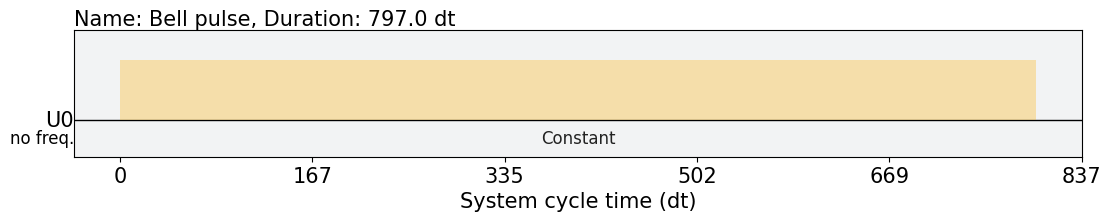

In [1210]:
esque_pul(parametros_optimos_2).draw()

In [1211]:
solver_closed = Solver(rotating_frame= w8*(a1dag @ a1 + a0 @ a0dag),
    rwa_cutoff_freq=2 * w8,
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7],
    hamiltonian_channels=["u0"],
    channel_carrier_freqs= {"u0":v8},
    dt=dt,
    array_library="jax",
)

In [1212]:
y0 = Statevector.from_label("00")
def evol_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_closed.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        atol=1e-10,
        rtol=1e-8
    )
   
    return sol

In [1213]:
def evol_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_closed.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        atol=1e-10,
        rtol=1e-8
    )
   
    return sol

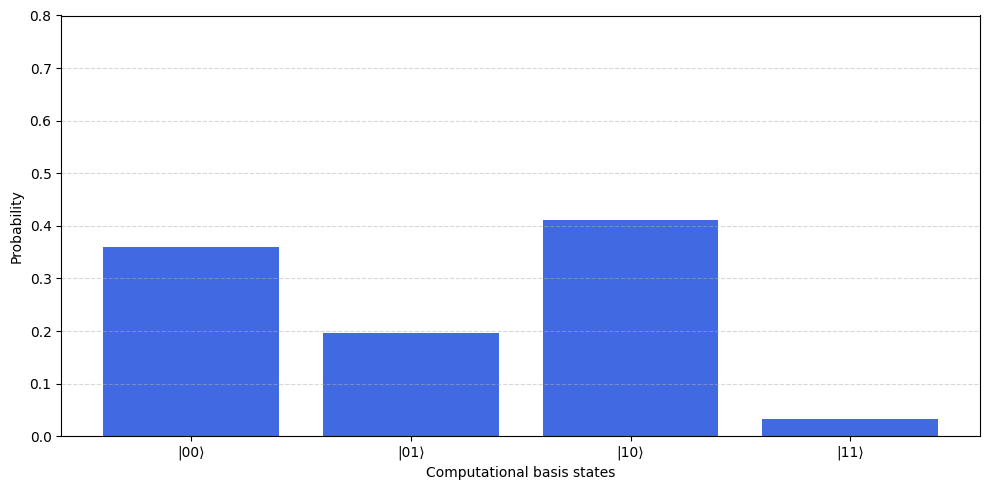

In [1214]:
plot_statevector_probabilities(objective_12(parametros_optimos_2))

In [1215]:
evol = evol_12(parametros_optimos_2)

nega_closed = []
for i in range(len(evol.t)):
    nega_closed.append(negativity(evol.y[i],[1]))
    


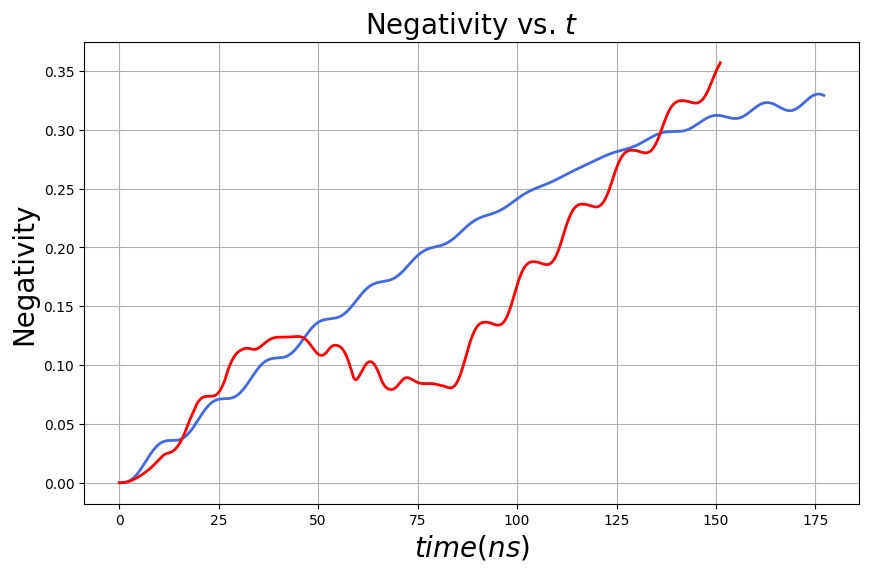

In [1216]:
    
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(evol.t,  nega_closed, color = 'royalblue', linewidth = 2, label = 'Negativity')
plt.plot(list_ta ,list_ya, color = "red", linewidth = 2)
# plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Negativity vs. $t$', fontsize = fontsize)
ax.grid()

In [1005]:
for i in range(len(evol.t)):
    print(evol.t[i], " ", i)

0.0   0
0.017571196097413186   1
0.03508754679255435   2
0.05309092446692018   3
0.07105546809982678   4
0.08889663274672074   5
0.10699309854001901   6
0.12567988552684792   7
0.14473218891254686   8
0.1637874901323301   9
0.1826960822707589   10
0.2016115174323511   11
0.22078586949290901   12
0.24019440050647384   13
0.25962348981227357   14
0.2789408077386605   15
0.29819638770883017   16
0.3175573853256089   17
0.3370731043334097   18
0.3566239958903487   19
0.376098775637701   20
0.3955000402903342   21
0.4149346050162042   22
0.4344750535825105   23
0.45406204602753064   24
0.4736026645020911   25
0.49307407186988156   26
0.5125410193582792   27
0.5320783595264756   28
0.5516683527329783   29
0.5712365793802147   30
0.5907456812588122   31
0.6102297954533464   32
0.6297558143837344   33
0.6493346749732096   34
0.6689118464885014   35
0.6884425939098201   36
0.7079381288212205   37
0.7274523252757228   38
0.7470140735165162   39
0.7665896101233888   40
0.7861326509592245   41
0.8

In [1008]:
list_tc  = []
list_yc = []
for i in range(3992):
    list_tc.append(evol.t[i])
    list_yc.append(negativity(evol.y[i],[1]))

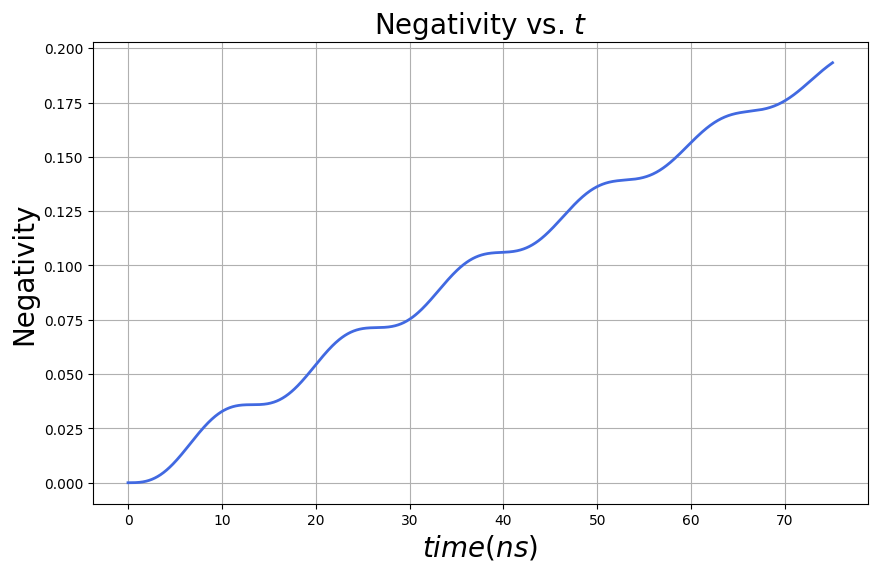

In [1027]:
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(list_tc,  list_yc, color = 'royalblue', linewidth = 2, label = 'Negativity')
# plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Negativity vs. $t$', fontsize = fontsize)
ax.grid()


ESTIMACIONES INICIALES
a0     = -2.1549354986e-03
b0     = 2.9029550778e-03
c0     = -4.4953348641e-06
A0     = 6.0131657304e-03
omega0 = 5.0213535283e-01
f0     = 7.9917323504e-02
phi0   = 0.0000000000e+00

PARÁMETROS DEL AJUSTE
a     = -7.9215626978e-04
b     = 2.8203328253e-03
c     = -3.4573114525e-06
A     = 4.8687890693e-03
omega = 4.7256439834e-01
phi   = 1.5945282724e+00

VARIANZAS Y ERRORES DE LOS PARÁMETROS

a
Valor          = -7.9215626978e-04
Varianza       = 6.4437440693e-10
Error estándar = 2.5384530859e-05
Valor ± error  = -7.9215626978e-04 ± 2.5384530859e-05

b
Valor          = 2.8203328253e-03
Varianza       = 2.4545166128e-12
Error estándar = 1.5666896990e-06
Valor ± error  = 2.8203328253e-03 ± 1.5666896990e-06

c
Valor          = -3.4573114525e-06
Varianza       = 4.1091677678e-16
Error estándar = 2.0271082279e-08
Valor ± error  = -3.4573114525e-06 ± 2.0271082279e-08

A
Valor          = 4.8687890693e-03
Varianza       = 1.4235092644e-10
Error estándar = 1.1931090748

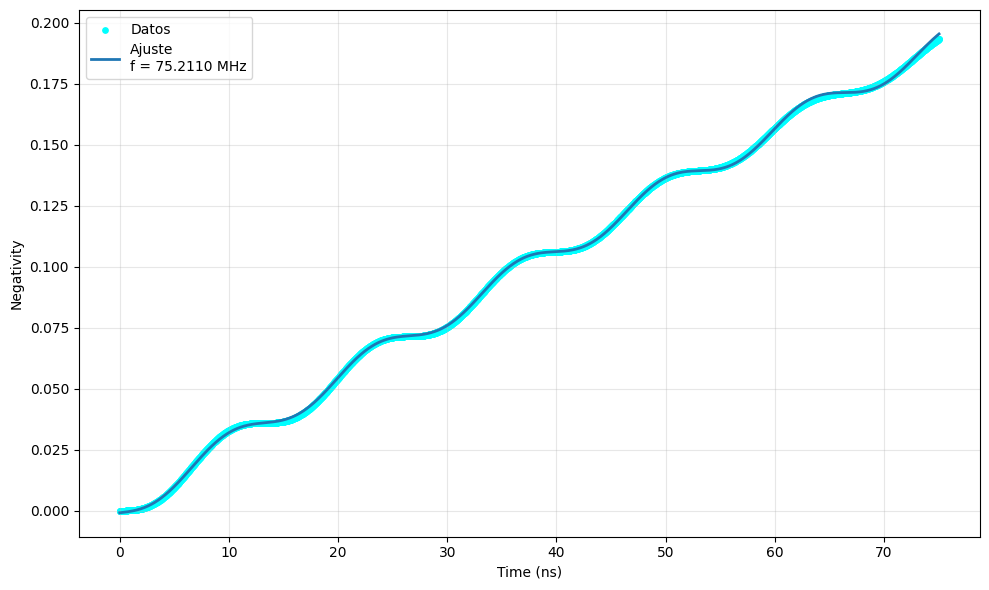

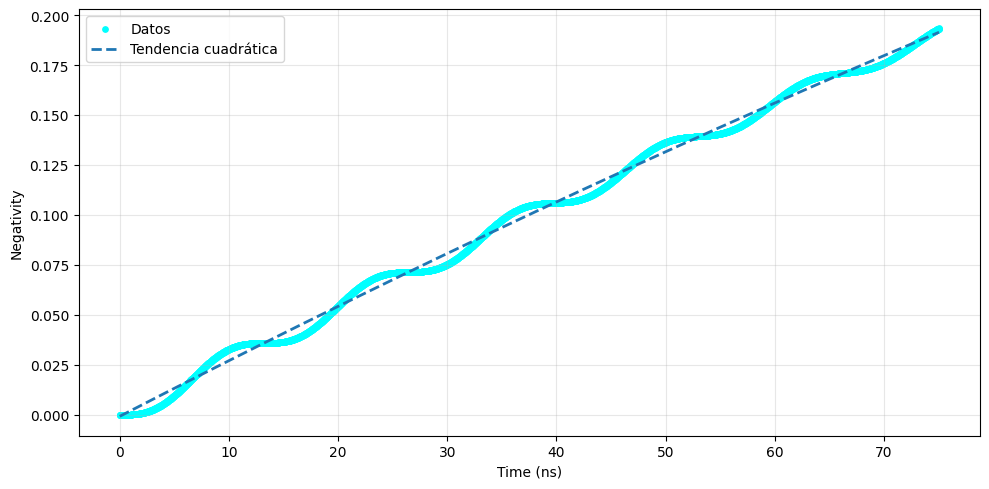

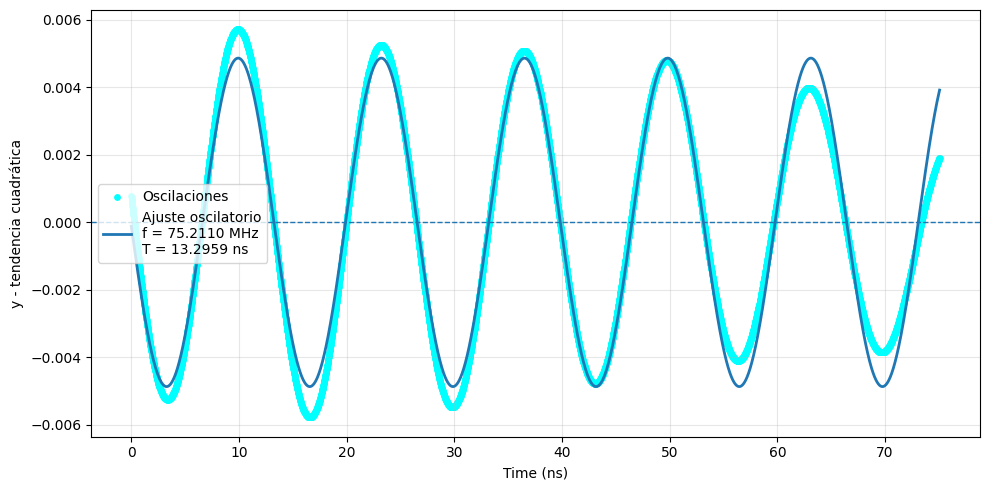



################################################
#              RESULTADO FINAL                 #
################################################

Modelo:
y(t) = a + b*t + c*t² + A*cos(omega*t + phi)

Parámetros:
a     = -7.92156270e-04 ± 2.54e-05
b     = 2.82033283e-03 ± 1.57e-06
c     = -3.45731145e-06 ± 2.03e-08
A     = 4.86878907e-03 ± 1.19e-05
omega = 4.72564398e-01 ± 1.11e-04
phi   = 1.59452827e+00 ± 4.84e-03

-----------------------------------------------
FRECUENCIA DE LAS OSCILACIONES
-----------------------------------------------
omega = 4.72564398e-01 ± 1.11e-04 rad/ns
f     = 75.21095992 ± 0.01771359 MHz
T     = 13.29593454 ± 0.00313144 ns

-----------------------------------------------
CALIDAD DEL AJUSTE
-----------------------------------------------
R²   = 0.99991150
RMSE = 5.23260938e-04
MAE  = 4.09131717e-04

################################################


In [1043]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# DATOS
# ============================================================

x = np.asarray(list_tc, dtype=float)
y = np.asarray(list_yc, dtype=float)

# Eliminar NaN e infinitos
mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]

# Ordenar por tiempo
idx = np.argsort(x)

x = x[idx]
y = y[idx]


# ============================================================
# MODELO
#
# y(t) = a + b*t + c*t^2 + A*cos(omega*t + phi)
# ============================================================

def modelo(x, a, b, c, A, omega, phi):
    return (
        a
        + b*x
        + c*x**2
        + A*np.cos(omega*x + phi)
    )


# ============================================================
# ESTIMACIONES INICIALES
# ============================================================

# Ajuste polinomial inicial de segundo grado
c0, b0, a0 = np.polyfit(x, y, 2)

# Eliminar tendencia cuadrática
y_detrend = y - (a0 + b0*x + c0*x**2)

# Intervalo temporal promedio
dt = np.mean(np.diff(x))

# FFT
frecuencias = np.fft.rfftfreq(
    len(x),
    d=dt
)

fft_y = np.abs(
    np.fft.rfft(y_detrend)
)

# Ignorar frecuencia cero
indice = np.argmax(fft_y[1:]) + 1

# Frecuencia inicial
f0 = frecuencias[indice]

# Frecuencia angular inicial
omega0 = 2*np.pi*f0

# Amplitud inicial
A0 = (
    np.max(y_detrend)
    - np.min(y_detrend)
) / 2

# Fase inicial
phi0 = 0


# Vector inicial
p0 = [
    a0,
    b0,
    c0,
    A0,
    omega0,
    phi0
]


print("\n==============================================")
print("ESTIMACIONES INICIALES")
print("==============================================")

print(f"a0     = {a0:.10e}")
print(f"b0     = {b0:.10e}")
print(f"c0     = {c0:.10e}")
print(f"A0     = {A0:.10e}")
print(f"omega0 = {omega0:.10e}")
print(f"f0     = {f0:.10e}")
print(f"phi0   = {phi0:.10e}")


# ============================================================
# AJUSTE NO LINEAL
# ============================================================

parametros, covarianza = curve_fit(
    modelo,
    x,
    y,
    p0=p0,
    bounds=(
        [
            -np.inf,
            -np.inf,
            -np.inf,
            -np.inf,
            0,
            -2*np.pi
        ],
        [
            np.inf,
            np.inf,
            np.inf,
            np.inf,
            np.inf,
            2*np.pi
        ]
    ),
    maxfev=500000
)


# ============================================================
# PARÁMETROS AJUSTADOS
# ============================================================

a, b, c, A, omega, phi = parametros


print("\n==============================================")
print("PARÁMETROS DEL AJUSTE")
print("==============================================")

print(f"a     = {a:.10e}")
print(f"b     = {b:.10e}")
print(f"c     = {c:.10e}")
print(f"A     = {A:.10e}")
print(f"omega = {omega:.10e}")
print(f"phi   = {phi:.10e}")


# ============================================================
# VARIANZAS Y ERRORES ESTÁNDAR
# ============================================================

varianzas = np.diag(covarianza)

errores = np.sqrt(varianzas)

nombres = [
    "a",
    "b",
    "c",
    "A",
    "omega",
    "phi"
]


print("\n==============================================")
print("VARIANZAS Y ERRORES DE LOS PARÁMETROS")
print("==============================================")


for nombre, valor, var, error in zip(
    nombres,
    parametros,
    varianzas,
    errores
):

    print(f"\n{nombre}")

    print(f"Valor          = {valor:.10e}")

    print(f"Varianza       = {var:.10e}")

    print(f"Error estándar = {error:.10e}")

    print(
        f"Valor ± error  = "
        f"{valor:.10e} ± {error:.10e}"
    )


# ============================================================
# FRECUENCIA Y PERÍODO
# ============================================================

error_omega = errores[4]

# Frecuencia ordinaria
f = omega / (2*np.pi)

# Error de frecuencia
error_f = error_omega / (2*np.pi)

# Período
T = 2*np.pi / omega

# Error del período
error_T = (
    (2*np.pi / omega**2)
    * error_omega
)


print("\n==============================================")
print("FRECUENCIA DE LAS OSCILACIONES")
print("==============================================")

print("Frecuencia angular:")

print(
    f"omega = {omega:.10e} "
    f"± {error_omega:.10e}"
)

print("\nFrecuencia:")

print(
    f"f = {f:.10e} "
    f"± {error_f:.10e}"
)

print("\nPeríodo:")

print(
    f"T = {T:.10e} "
    f"± {error_T:.10e}"
)


# ============================================================
# CONVERSIÓN A MHz
# ============================================================

# Si x está en ns:
#
# f está en ciclos/ns
# 1 ciclo/ns = 1000 MHz

f_MHz = f * 1000
error_f_MHz = error_f * 1000

print("\n----------------------------------------------")
print("FRECUENCIA EN MHz")
print("----------------------------------------------")

print(
    f"f = {f_MHz:.8f} "
    f"± {error_f_MHz:.8f} MHz"
)


# ============================================================
# INTERVALO DE CONFIANZA 95 %
# ============================================================

z = 1.96

print("\n==============================================")
print("INTERVALOS DE CONFIANZA DEL 95 %")
print("==============================================")


for nombre, valor, error in zip(
    nombres,
    parametros,
    errores
):

    inferior = valor - z*error

    superior = valor + z*error

    print(
        f"{nombre}: "
        f"{valor:.8e} "
        f"[{inferior:.8e}, "
        f"{superior:.8e}]"
    )


# ============================================================
# PREDICCIÓN DEL MODELO
# ============================================================

y_pred = modelo(
    x,
    a,
    b,
    c,
    A,
    omega,
    phi
)


# ============================================================
# RESIDUOS
# ============================================================

residuos = y - y_pred


# ============================================================
# R²
# ============================================================

ss_res = np.sum(residuos**2)

ss_tot = np.sum(
    (y - np.mean(y))**2
)

R2 = 1 - ss_res/ss_tot


# ============================================================
# MÉTRICAS DE ERROR
# ============================================================

N = len(y)

k = len(parametros)

grados_libertad = N - k

# SSE
SSE = np.sum(residuos**2)

# MSE
MSE = np.mean(residuos**2)

# RMSE
RMSE = np.sqrt(MSE)

# MAE
MAE = np.mean(np.abs(residuos))

# Varianza residual
varianza_residual = (
    SSE / grados_libertad
)

# Desviación estándar residual
sigma_residual = np.sqrt(
    varianza_residual
)

# Error máximo
max_error = np.max(
    np.abs(residuos)
)


print("\n==============================================")
print("CALIDAD DEL AJUSTE")
print("==============================================")

print(
    f"Número de datos        = {N}"
)

print(
    f"Parámetros             = {k}"
)

print(
    f"Grados de libertad     = "
    f"{grados_libertad}"
)

print(
    f"\nR²                    = "
    f"{R2:.10f}"
)

print(
    f"SSE                   = "
    f"{SSE:.10e}"
)

print(
    f"MSE                   = "
    f"{MSE:.10e}"
)

print(
    f"RMSE                  = "
    f"{RMSE:.10e}"
)

print(
    f"MAE                   = "
    f"{MAE:.10e}"
)

print(
    f"Varianza residual     = "
    f"{varianza_residual:.10e}"
)

print(
    f"Desviación residual   = "
    f"{sigma_residual:.10e}"
)

print(
    f"Máximo error absoluto = "
    f"{max_error:.10e}"
)


# ============================================================
# MATRIZ DE COVARIANZA
# ============================================================

print("\n==============================================")
print("MATRIZ DE COVARIANZA")
print("==============================================")

print(covarianza)


# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================

correlacion = np.zeros_like(covarianza)

for i in range(len(parametros)):

    for j in range(len(parametros)):

        denominador = np.sqrt(
            covarianza[i, i]
            * covarianza[j, j]
        )

        if denominador != 0:

            correlacion[i, j] = (
                covarianza[i, j]
                / denominador
            )

        else:

            correlacion[i, j] = np.nan


print("\n==============================================")
print("MATRIZ DE CORRELACIÓN")
print("==============================================")

print(correlacion)


# ============================================================
# CURVA AJUSTADA
# ============================================================

x_fit = np.linspace(
    x.min(),
    x.max(),
    100000
)

y_fit = modelo(
    x_fit,
    a,
    b,
    c,
    A,
    omega,
    phi
)


# ============================================================
# TENDENCIA CUADRÁTICA
# ============================================================

tendencia = (
    a
    + b*x_fit
    + c*x_fit**2
)


# ============================================================
# OSCILACIÓN AJUSTADA
# ============================================================

oscilacion_fit = (
    A*np.cos(
        omega*x_fit + phi
    )
)


# ============================================================
# GRÁFICA: DATOS + AJUSTE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    s=15,
    color="cyan",
    label="Datos"
)

plt.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label=(
        f"Ajuste\n"
        f"f = {f_MHz:.4f} MHz"
    )
)

plt.xlabel("Time (ns)")

plt.ylabel("Negativity")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: TENDENCIA CUADRÁTICA
# ============================================================

plt.figure(figsize=(10, 5))

plt.scatter(
    x,
    y,
    s=15,
    color="cyan",
    label="Datos"
)

plt.plot(
    x_fit,
    tendencia,
    "--",
    linewidth=2,
    label="Tendencia cuadrática"
)

plt.xlabel("Time (ns)")

plt.ylabel("Negativity")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: OSCILACIONES
# ============================================================

plt.figure(figsize=(10, 5))

# Quitar la tendencia cuadrática de los datos
oscilacion = (
    y
    - (
        a
        + b*x
        + c*x**2
    )
)


plt.scatter(
    x,
    oscilacion,
    s=15,
    color="cyan",
    label="Oscilaciones"
)

plt.plot(
    x_fit,
    oscilacion_fit,
    linewidth=2,
    label=(
        f"Ajuste oscilatorio\n"
        f"f = {f_MHz:.4f} MHz\n"
        f"T = {T:.4f} ns"
    )
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (ns)")

plt.ylabel(
    "y - tendencia cuadrática"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n")

print("################################################")

print("#              RESULTADO FINAL                 #")

print("################################################")


print("\nModelo:")

print(
    "y(t) = a + b*t + c*t² "
    "+ A*cos(omega*t + phi)"
)


print("\nParámetros:")

print(
    f"a     = {a:.8e} ± "
    f"{errores[0]:.2e}"
)

print(
    f"b     = {b:.8e} ± "
    f"{errores[1]:.2e}"
)

print(
    f"c     = {c:.8e} ± "
    f"{errores[2]:.2e}"
)

print(
    f"A     = {A:.8e} ± "
    f"{errores[3]:.2e}"
)

print(
    f"omega = {omega:.8e} ± "
    f"{errores[4]:.2e}"
)

print(
    f"phi   = {phi:.8e} ± "
    f"{errores[5]:.2e}"
)


print("\n-----------------------------------------------")
print("FRECUENCIA DE LAS OSCILACIONES")
print("-----------------------------------------------")


print(
    f"omega = {omega:.8e} ± "
    f"{error_omega:.2e} rad/ns"
)

print(
    f"f     = {f_MHz:.8f} ± "
    f"{error_f_MHz:.8f} MHz"
)

print(
    f"T     = {T:.8f} ± "
    f"{error_T:.8f} ns"
)


print("\n-----------------------------------------------")
print("CALIDAD DEL AJUSTE")
print("-----------------------------------------------")

print(f"R²   = {R2:.8f}")

print(f"RMSE = {RMSE:.8e}")

print(f"MAE  = {MAE:.8e}")

print("\n################################################")

In [ ]:



# Abre (o crea) el archivo en modo escritura ('w')
with open("archivos.txt", "w", encoding="utf-8") as archivo:
    for elemento in list_tc:
        # Escribe cada elemento seguido de un salto de línea
        archivo.write(str(elemento) + "\n")


In [1011]:
# Abre (o crea) el archivo en modo escritura ('w')
with open("negati_cerrado.txt", "w", encoding="utf-8") as archivo:
    for elemento in list_yc:
        # Escribe cada elemento seguido de un salto de línea
        archivo.write(str(elemento) + "\n")

In [1015]:
def omega_mas(w0,w1,k):
    w_mas = (w0 + w1)/2 + np.sqrt(k**2 + ((w0 - w1)/2)**2)
    return w_mas

def omega_menos(w0,w1,k):
    w_menos = (w0 + w1)/2 - np.sqrt(k**2 + ((w0 - w1)/2)**2)
    return w_menos

In [1016]:
omega_menos(w7,w8,J78)

np.float64(29.879792070736507)

In [1018]:
omega_mas(w7,w8,J78)

np.float64(30.23847391912225)

In [1024]:
(omega_mas(w7,w8,J78) - omega_menos(w7,w8,J78))/(2*np.pi)

np.float64(0.05708598916792873)


ESTIMACIONES INICIALES
a0      = 2.0984598132e-03
b0      = 2.5648592740e-03

Componente 1:
A01     = 2.3762557388e-03
omega01 = 8.3689225472e-02
f01     = 1.3319553917e-02

Componente 2:
A02     = 2.3762557388e-03
omega02 = 3.3475690189e-01
f02     = 5.3278215670e-02

Componente 3:
A03     = 2.3762557388e-03
omega03 = 5.0213535283e-01
f03     = 7.9917323504e-02

PARÁMETROS DEL AJUSTE
a      = -2.0506685412e-03
b      = -1.2981866552e-03

Componente 1:
A1     = -5.9295536829e-01
omega1 = 6.7667350746e-03
phi1   = 1.5742424115e+00

Componente 2:
A2     = -2.9870177217e-03
omega2 = 4.6100693399e-01
phi2   = -1.5500367789e+00

Componente 3:
A3     = 2.7289945565e-03
omega3 = 4.8744997389e-01
phi3   = 1.5482339916e+00

VARIANZAS Y ERRORES

a
Valor          = -2.0506685412e-03
Varianza       = 2.0383609739e-08
Error estándar = 1.4277117965e-04
Valor ± error  = -2.0506685412e-03 ± 1.4277117965e-04

b
Valor          = -1.2981866552e-03
Varianza       = 1.0966446902e-08
Error estándar = 1.047

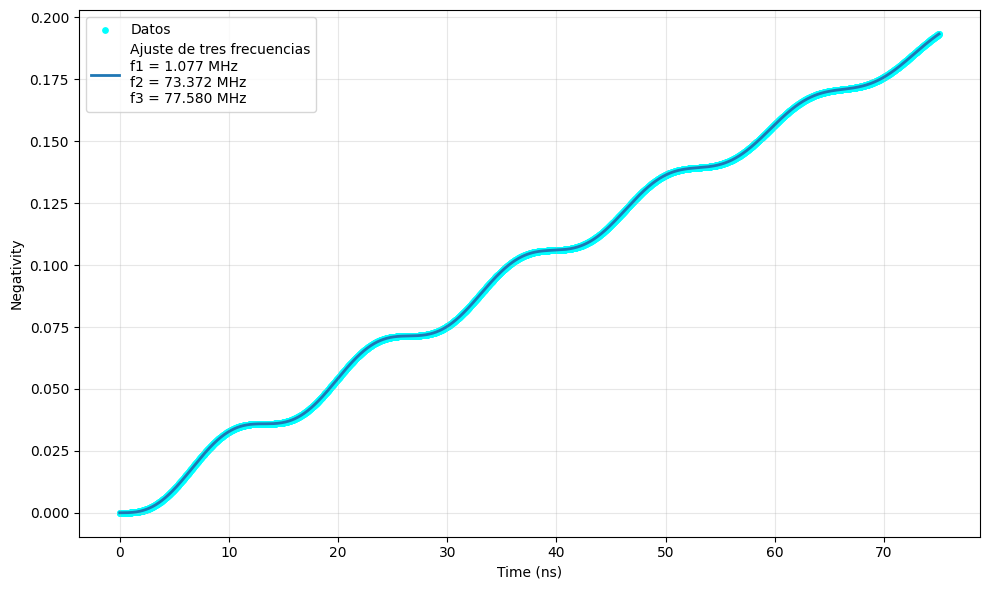

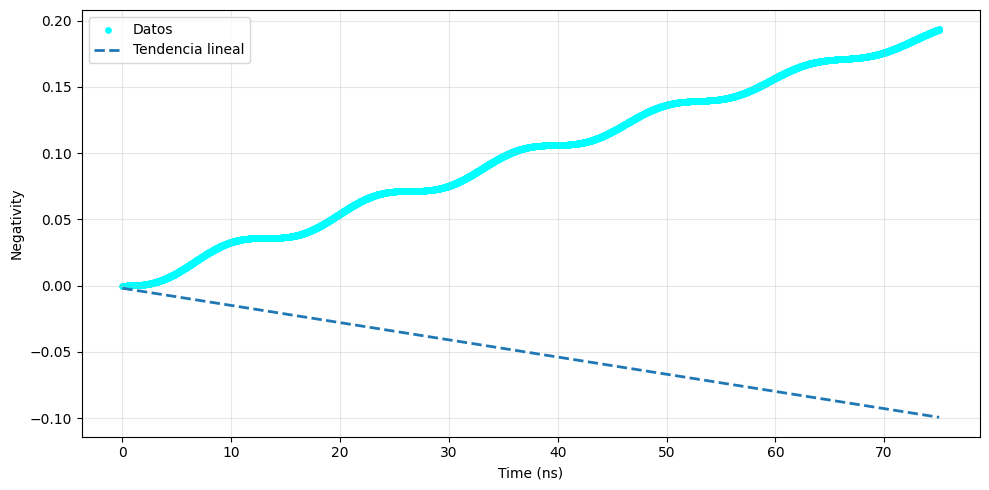

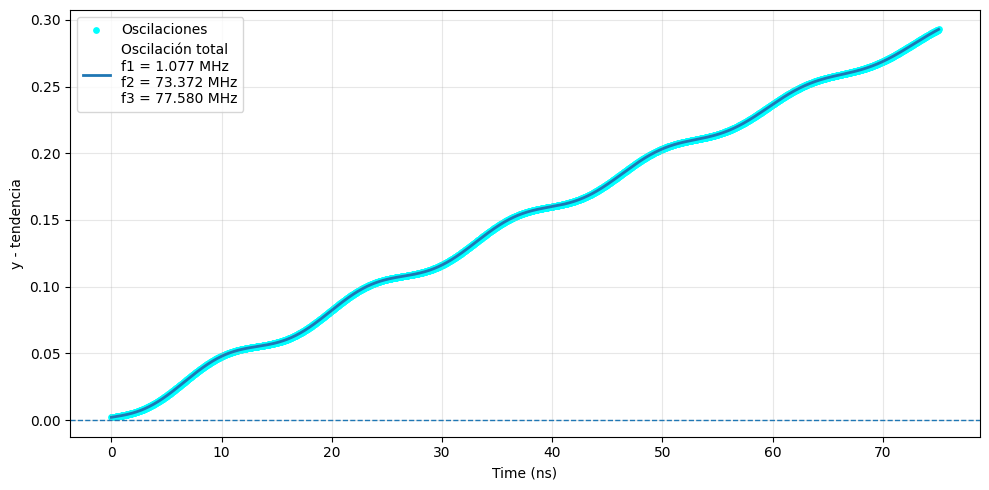

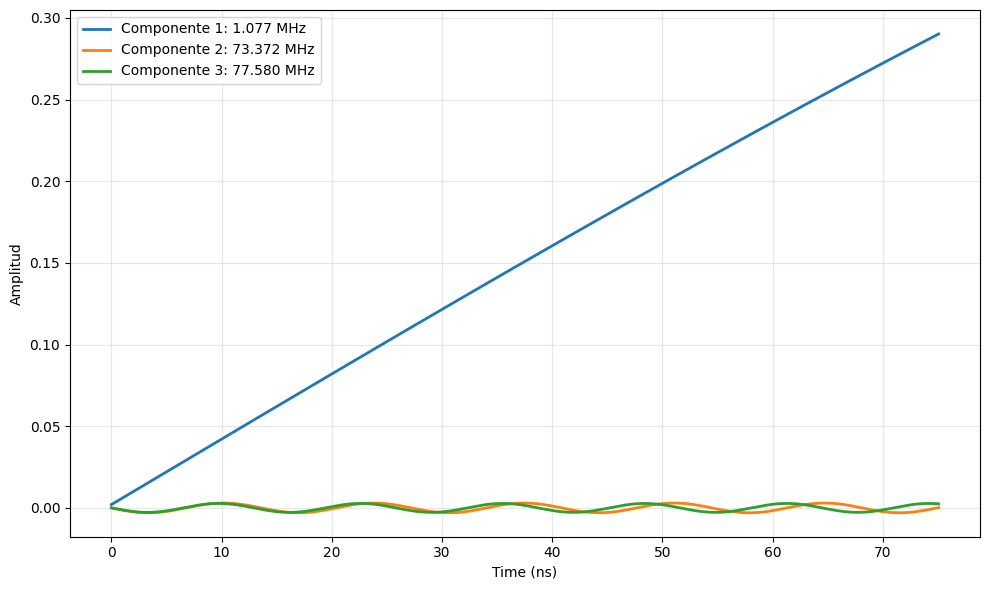



################################################
#              RESULTADO FINAL                 #
################################################

Modelo:
y(t) = a + b*t + A1*cos(w1*t + phi1) + A2*cos(w2*t + phi2) + A3*cos(w3*t + phi3)

Parámetros:
a = -2.05066854e-03 ± 1.43e-04
b = -1.29818666e-03 ± 1.05e-04

Componente 1:
A1 = -5.92955368e-01 ± 2.35e-02
omega1 = 6.76673507e-03 ± 9.16e-05 rad/ns
phi1 = 1.57424241e+00 ± 1.13e-04
f1 = 1.07695934 ± 0.01457796 MHz
T1 = 928.54016566 ± 12.56892259 ns

Componente 2:
A2 = -2.98701772e-03 ± 8.53e-07
omega2 = 4.61006934e-01 ± 5.81e-06 rad/ns
phi2 = -1.55003678e+00 ± 1.93e-04
f2 = 73.37153234 ± 0.00092412 MHz
T2 = 13.62926421 ± 0.00017166 ns

Componente 3:
A3 = 2.72899456e-03 ± 8.32e-07
omega3 = 4.87449974e-01 ± 5.73e-06 rad/ns
phi3 = 1.54823399e+00 ± 2.05e-04
f3 = 77.58007285 ± 0.00091214 MHz
T3 = 12.88990798 ± 0.00015155 ns

-----------------------------------------------
CALIDAD DEL AJUSTE
-----------------------------------------------
R²

In [1185]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# DATOS
# ============================================================

x = np.asarray(list_tc, dtype=float)
y = np.asarray(list_yc, dtype=float)

# Eliminar NaN e infinitos
mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]

# Ordenar por tiempo
idx = np.argsort(x)

x = x[idx]
y = y[idx]


# ============================================================
# MODELO
#
# y(t) = a + b*t
#      + A1*cos(w1*t + phi1)
#      + A2*cos(w2*t + phi2)
#      + A3*cos(w3*t + phi3)
# ============================================================

def modelo(
    x,
    a,
    b,
    A1, omega1, phi1,
    A2, omega2, phi2,
    A3, omega3, phi3
):

    return (
        a
        + b*x

        + A1*np.cos(
            omega1*x + phi1
        )

        + A2*np.cos(
            omega2*x + phi2
        )

        + A3*np.cos(
            omega3*x + phi3
        )
    )


# ============================================================
# ESTIMACIONES INICIALES
# ============================================================

# ------------------------------------------------------------
# Tendencia lineal
# ------------------------------------------------------------

b0, a0 = np.polyfit(x, y, 1)

# Eliminar tendencia
y_detrend = y - (a0 + b0*x)


# ------------------------------------------------------------
# FFT
# ------------------------------------------------------------

dt = np.mean(np.diff(x))

frecuencias = np.fft.rfftfreq(
    len(x),
    d=dt
)

fft_y = np.abs(
    np.fft.rfft(y_detrend)
)


# Ignorar frecuencia cero
fft_y[0] = 0


# ------------------------------------------------------------
# Buscar los 3 picos principales
# ------------------------------------------------------------

indices_ordenados = np.argsort(
    fft_y
)[::-1]


indices_picos = []

for indice in indices_ordenados:

    # Evitar frecuencias demasiado cercanas
    if all(
        abs(
            frecuencias[indice]
            - frecuencias[j]
        )
        > 1.0 / (
            x.max() - x.min()
        )
        for j in indices_picos
    ):

        indices_picos.append(indice)

    if len(indices_picos) == 3:
        break


# Ordenar las frecuencias
indices_picos = sorted(
    indices_picos,
    key=lambda i: frecuencias[i]
)


# ------------------------------------------------------------
# Frecuencias iniciales
# ------------------------------------------------------------

f01 = frecuencias[indices_picos[0]]
f02 = frecuencias[indices_picos[1]]
f03 = frecuencias[indices_picos[2]]


# Frecuencias angulares iniciales
omega01 = 2*np.pi*f01
omega02 = 2*np.pi*f02
omega03 = 2*np.pi*f03


# ------------------------------------------------------------
# Amplitudes iniciales
# ------------------------------------------------------------

A01 = (
    np.max(y_detrend)
    - np.min(y_detrend)
) / 6

A02 = A01
A03 = A01


# Fases iniciales
phi01 = 0
phi02 = 0
phi03 = 0


# ============================================================
# VECTOR INICIAL
# ============================================================

p0 = [

    a0,
    b0,

    A01,
    omega01,
    phi01,

    A02,
    omega02,
    phi02,

    A03,
    omega03,
    phi03
]


# ============================================================
# ESTIMACIONES INICIALES
# ============================================================

print("\n==============================================")
print("ESTIMACIONES INICIALES")
print("==============================================")

print(f"a0      = {a0:.10e}")
print(f"b0      = {b0:.10e}")

print("\nComponente 1:")
print(f"A01     = {A01:.10e}")
print(f"omega01 = {omega01:.10e}")
print(f"f01     = {f01:.10e}")

print("\nComponente 2:")
print(f"A02     = {A02:.10e}")
print(f"omega02 = {omega02:.10e}")
print(f"f02     = {f02:.10e}")

print("\nComponente 3:")
print(f"A03     = {A03:.10e}")
print(f"omega03 = {omega03:.10e}")
print(f"f03     = {f03:.10e}")


# ============================================================
# AJUSTE NO LINEAL
# ============================================================

parametros, covarianza = curve_fit(

    modelo,

    x,
    y,

    p0=p0,

    bounds=(

        [

            -np.inf,
            -np.inf,

            -np.inf,
            0,
            -2*np.pi,

            -np.inf,
            0,
            -2*np.pi,

            -np.inf,
            0,
            -2*np.pi

        ],

        [

            np.inf,
            np.inf,

            np.inf,
            np.inf,
            2*np.pi,

            np.inf,
            np.inf,
            2*np.pi,

            np.inf,
            np.inf,
            2*np.pi

        ]

    ),

    maxfev=1000000
)


# ============================================================
# PARÁMETROS AJUSTADOS
# ============================================================

(
    a,
    b,

    A1,
    omega1,
    phi1,

    A2,
    omega2,
    phi2,

    A3,
    omega3,
    phi3

) = parametros


# ============================================================
# RESULTADOS DEL AJUSTE
# ============================================================

print("\n==============================================")
print("PARÁMETROS DEL AJUSTE")
print("==============================================")

print(f"a      = {a:.10e}")
print(f"b      = {b:.10e}")

print("\nComponente 1:")
print(f"A1     = {A1:.10e}")
print(f"omega1 = {omega1:.10e}")
print(f"phi1   = {phi1:.10e}")

print("\nComponente 2:")
print(f"A2     = {A2:.10e}")
print(f"omega2 = {omega2:.10e}")
print(f"phi2   = {phi2:.10e}")

print("\nComponente 3:")
print(f"A3     = {A3:.10e}")
print(f"omega3 = {omega3:.10e}")
print(f"phi3   = {phi3:.10e}")


# ============================================================
# ERRORES ESTÁNDAR
# ============================================================

varianzas = np.diag(covarianza)

errores = np.sqrt(
    np.abs(varianzas)
)


nombres = [

    "a",
    "b",

    "A1",
    "omega1",
    "phi1",

    "A2",
    "omega2",
    "phi2",

    "A3",
    "omega3",
    "phi3"

]


print("\n==============================================")
print("VARIANZAS Y ERRORES")
print("==============================================")


for nombre, valor, var, error in zip(

    nombres,
    parametros,
    varianzas,
    errores

):

    print(f"\n{nombre}")

    print(
        f"Valor          = "
        f"{valor:.10e}"
    )

    print(
        f"Varianza       = "
        f"{var:.10e}"
    )

    print(
        f"Error estándar = "
        f"{error:.10e}"
    )

    print(
        f"Valor ± error  = "
        f"{valor:.10e} ± "
        f"{error:.10e}"
    )


# ============================================================
# FRECUENCIAS
# ============================================================

error_omega1 = errores[3]
error_omega2 = errores[6]
error_omega3 = errores[9]


# Frecuencias ordinarias
f1 = omega1 / (2*np.pi)
f2 = omega2 / (2*np.pi)
f3 = omega3 / (2*np.pi)


# Errores de frecuencia
error_f1 = error_omega1 / (2*np.pi)
error_f2 = error_omega2 / (2*np.pi)
error_f3 = error_omega3 / (2*np.pi)


# ============================================================
# PERÍODOS
# ============================================================

T1 = 2*np.pi / omega1
T2 = 2*np.pi / omega2
T3 = 2*np.pi / omega3


error_T1 = (
    2*np.pi
    / omega1**2
    * error_omega1
)

error_T2 = (
    2*np.pi
    / omega2**2
    * error_omega2
)

error_T3 = (
    2*np.pi
    / omega3**2
    * error_omega3
)


# ============================================================
# CONVERSIÓN A MHz
# ============================================================

# x está en ns
#
# ciclos/ns -> GHz
# ciclos/ns * 1000 -> MHz

f1_MHz = f1 * 1000
f2_MHz = f2 * 1000
f3_MHz = f3 * 1000

error_f1_MHz = error_f1 * 1000
error_f2_MHz = error_f2 * 1000
error_f3_MHz = error_f3 * 1000


# ============================================================
# MOSTRAR FRECUENCIAS
# ============================================================

print("\n==============================================")
print("FRECUENCIAS DE LAS OSCILACIONES")
print("==============================================")

print("\nComponente 1:")

print(
    f"omega1 = {omega1:.10e} "
    f"± {error_omega1:.10e} rad/ns"
)

print(
    f"f1     = {f1_MHz:.8f} "
    f"± {error_f1_MHz:.8f} MHz"
)

print(
    f"T1     = {T1:.8f} "
    f"± {error_T1:.8f} ns"
)


print("\nComponente 2:")

print(
    f"omega2 = {omega2:.10e} "
    f"± {error_omega2:.10e} rad/ns"
)

print(
    f"f2     = {f2_MHz:.8f} "
    f"± {error_f2_MHz:.8f} MHz"
)

print(
    f"T2     = {T2:.8f} "
    f"± {error_T2:.8f} ns"
)


print("\nComponente 3:")

print(
    f"omega3 = {omega3:.10e} "
    f"± {error_omega3:.10e} rad/ns"
)

print(
    f"f3     = {f3_MHz:.8f} "
    f"± {error_f3_MHz:.8f} MHz"
)

print(
    f"T3     = {T3:.8f} "
    f"± {error_T3:.8f} ns"
)


# ============================================================
# INTERVALOS DE CONFIANZA 95 %
# ============================================================

z = 1.96

print("\n==============================================")
print("INTERVALOS DE CONFIANZA DEL 95 %")
print("==============================================")


for nombre, valor, error in zip(

    nombres,
    parametros,
    errores

):

    inferior = valor - z*error
    superior = valor + z*error

    print(
        f"{nombre}: "
        f"{valor:.8e} "
        f"[{inferior:.8e}, "
        f"{superior:.8e}]"
    )


# ============================================================
# PREDICCIÓN
# ============================================================

y_pred = modelo(

    x,

    a,
    b,

    A1,
    omega1,
    phi1,

    A2,
    omega2,
    phi2,

    A3,
    omega3,
    phi3

)


# ============================================================
# RESIDUOS
# ============================================================

residuos = y - y_pred


# ============================================================
# R²
# ============================================================

ss_res = np.sum(
    residuos**2
)

ss_tot = np.sum(
    (y - np.mean(y))**2
)

R2 = 1 - ss_res / ss_tot


# ============================================================
# MÉTRICAS
# ============================================================

N = len(y)

k = len(parametros)

grados_libertad = N - k


SSE = np.sum(
    residuos**2
)

MSE = np.mean(
    residuos**2
)

RMSE = np.sqrt(
    MSE
)

MAE = np.mean(
    np.abs(residuos)
)

varianza_residual = (
    SSE / grados_libertad
)

sigma_residual = np.sqrt(
    varianza_residual
)

max_error = np.max(
    np.abs(residuos)
)


print("\n==============================================")
print("CALIDAD DEL AJUSTE")
print("==============================================")

print(
    f"Número de datos        = {N}"
)

print(
    f"Parámetros             = {k}"
)

print(
    f"Grados de libertad     = "
    f"{grados_libertad}"
)

print(
    f"\nR²                    = "
    f"{R2:.10f}"
)

print(
    f"SSE                   = "
    f"{SSE:.10e}"
)

print(
    f"MSE                   = "
    f"{MSE:.10e}"
)

print(
    f"RMSE                  = "
    f"{RMSE:.10e}"
)

print(
    f"MAE                   = "
    f"{MAE:.10e}"
)

print(
    f"Varianza residual     = "
    f"{varianza_residual:.10e}"
)

print(
    f"Desviación residual   = "
    f"{sigma_residual:.10e}"
)

print(
    f"Máximo error absoluto = "
    f"{max_error:.10e}"
)


# ============================================================
# MATRIZ DE COVARIANZA
# ============================================================

print("\n==============================================")
print("MATRIZ DE COVARIANZA")
print("==============================================")

print(covarianza)


# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================

correlacion = np.zeros_like(
    covarianza
)

for i in range(
    len(parametros)
):

    for j in range(
        len(parametros)
    ):

        denominador = np.sqrt(

            abs(
                covarianza[i, i]
                * covarianza[j, j]
            )

        )

        if denominador != 0:

            correlacion[i, j] = (

                covarianza[i, j]
                / denominador

            )

        else:

            correlacion[i, j] = np.nan


print("\n==============================================")
print("MATRIZ DE CORRELACIÓN")
print("==============================================")

print(correlacion)


# ============================================================
# CURVA AJUSTADA
# ============================================================

x_fit = np.linspace(

    x.min(),
    x.max(),
    100000

)


y_fit = modelo(

    x_fit,

    a,
    b,

    A1,
    omega1,
    phi1,

    A2,
    omega2,
    phi2,

    A3,
    omega3,
    phi3

)


# ============================================================
# TENDENCIA LINEAL
# ============================================================

tendencia = (
    a + b*x_fit
)


# ============================================================
# COMPONENTES INDIVIDUALES
# ============================================================

oscilacion1_fit = (
    A1*np.cos(
        omega1*x_fit + phi1
    )
)

oscilacion2_fit = (
    A2*np.cos(
        omega2*x_fit + phi2
    )
)

oscilacion3_fit = (
    A3*np.cos(
        omega3*x_fit + phi3
    )
)


# Oscilación total
oscilacion_total_fit = (

    oscilacion1_fit
    + oscilacion2_fit
    + oscilacion3_fit

)


# ============================================================
# GRÁFICA: DATOS + AJUSTE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(

    x,
    y,

    s=15,
    color="cyan",

    label="Datos"

)

plt.plot(

    x_fit,
    y_fit,

    linewidth=2,

    label=(
        "Ajuste de tres frecuencias\n"
        f"f1 = {f1_MHz:.3f} MHz\n"
        f"f2 = {f2_MHz:.3f} MHz\n"
        f"f3 = {f3_MHz:.3f} MHz"
    )

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "Negativity"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: TENDENCIA
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.scatter(

    x,
    y,

    s=15,
    color="cyan",

    label="Datos"

)

plt.plot(

    x_fit,
    tendencia,

    "--",

    linewidth=2,

    label="Tendencia lineal"

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "Negativity"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: OSCILACIÓN TOTAL
# ============================================================

oscilacion = (
    y - (a + b*x)
)


plt.figure(
    figsize=(10, 5)
)

plt.scatter(

    x,
    oscilacion,

    s=15,
    color="cyan",

    label="Oscilaciones"

)

plt.plot(

    x_fit,
    oscilacion_total_fit,

    linewidth=2,

    label=(
        "Oscilación total\n"
        f"f1 = {f1_MHz:.3f} MHz\n"
        f"f2 = {f2_MHz:.3f} MHz\n"
        f"f3 = {f3_MHz:.3f} MHz"
    )

)

plt.axhline(

    0,

    linestyle="--",

    linewidth=1

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "y - tendencia"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRÁFICA: COMPONENTES INDIVIDUALES
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(

    x_fit,
    oscilacion1_fit,

    linewidth=2,

    label=f"Componente 1: {f1_MHz:.3f} MHz"

)

plt.plot(

    x_fit,
    oscilacion2_fit,

    linewidth=2,

    label=f"Componente 2: {f2_MHz:.3f} MHz"

)

plt.plot(

    x_fit,
    oscilacion3_fit,

    linewidth=2,

    label=f"Componente 3: {f3_MHz:.3f} MHz"

)

plt.xlabel(
    "Time (ns)"
)

plt.ylabel(
    "Amplitud"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n")

print("################################################")
print("#              RESULTADO FINAL                 #")
print("################################################")


print("\nModelo:")

print(
    "y(t) = a + b*t "
    "+ A1*cos(w1*t + phi1) "
    "+ A2*cos(w2*t + phi2) "
    "+ A3*cos(w3*t + phi3)"
)


print("\nParámetros:")

print(
    f"a = {a:.8e} ± "
    f"{errores[0]:.2e}"
)

print(
    f"b = {b:.8e} ± "
    f"{errores[1]:.2e}"
)


print("\nComponente 1:")

print(
    f"A1 = {A1:.8e} ± "
    f"{errores[2]:.2e}"
)

print(
    f"omega1 = {omega1:.8e} ± "
    f"{errores[3]:.2e} rad/ns"
)

print(
    f"phi1 = {phi1:.8e} ± "
    f"{errores[4]:.2e}"
)

print(
    f"f1 = {f1_MHz:.8f} ± "
    f"{error_f1_MHz:.8f} MHz"
)

print(
    f"T1 = {T1:.8f} ± "
    f"{error_T1:.8f} ns"
)


print("\nComponente 2:")

print(
    f"A2 = {A2:.8e} ± "
    f"{errores[5]:.2e}"
)

print(
    f"omega2 = {omega2:.8e} ± "
    f"{errores[6]:.2e} rad/ns"
)

print(
    f"phi2 = {phi2:.8e} ± "
    f"{errores[7]:.2e}"
)

print(
    f"f2 = {f2_MHz:.8f} ± "
    f"{error_f2_MHz:.8f} MHz"
)

print(
    f"T2 = {T2:.8f} ± "
    f"{error_T2:.8f} ns"
)


print("\nComponente 3:")

print(
    f"A3 = {A3:.8e} ± "
    f"{errores[8]:.2e}"
)

print(
    f"omega3 = {omega3:.8e} ± "
    f"{errores[9]:.2e} rad/ns"
)

print(
    f"phi3 = {phi3:.8e} ± "
    f"{errores[10]:.2e}"
)

print(
    f"f3 = {f3_MHz:.8f} ± "
    f"{error_f3_MHz:.8f} MHz"
)

print(
    f"T3 = {T3:.8f} ± "
    f"{error_T3:.8f} ns"
)


print("\n-----------------------------------------------")
print("CALIDAD DEL AJUSTE")
print("-----------------------------------------------")

print(
    f"R²   = {R2:.8f}"
)

print(
    f"RMSE = {RMSE:.8e}"
)

print(
    f"MAE  = {MAE:.8e}"
)

print("\n################################################")

In [1187]:
print(v7, "\t", v8,  "\t", J78, "\t", r0, "\t", r1, delta7, "\t", delta7 )

4.755587722216812 	 4.812531480182586 	 0.012651918734551187 	 0.39575797919595557 	 0.6501466069370565 -1.9540951675249636 	 -1.9540951675249636


In [1217]:
def plot_populations(sol):
    pop0 = [psi.probabilities()[0] for psi in evol.y]
    pop1 = [psi.probabilities()[1] for psi in evol.y]
    pop2 = [psi.probabilities()[2] for psi in evol.y]
    pop3 = [psi.probabilities()[3] for psi in evol.y]

    fig = plt.figure(figsize=(8, 5))
    plt.plot(sol.t, pop0, lw=3, label="Population in |00>")
    plt.plot(sol.t, pop1, lw=3, label="Population in |01>")
    plt.plot(sol.t, pop2, lw=3, label="Population in |10>")
    plt.plot(sol.t, pop3, lw=3, label="Population in |11>")
    plt.xlabel("Time (ns)")
    plt.ylabel("Population")
    plt.legend(frameon=False)
    plt.ylim([0, 1.05])
    plt.xlim([0, evol.t[-1]])
    # plt.vlines(T, 0, 1.05, "k", linestyle="dashed")

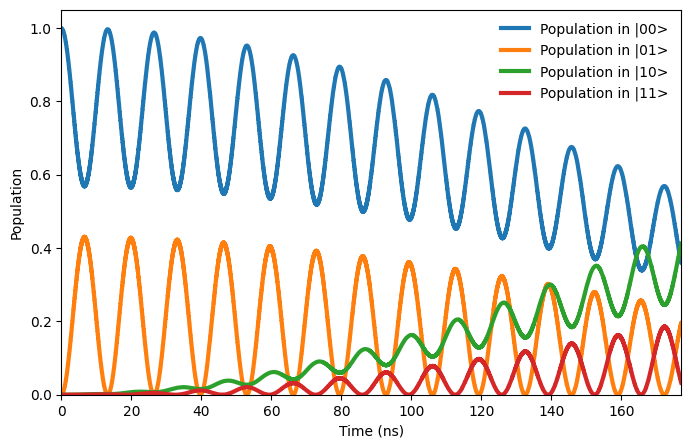

In [1218]:
plot_populations(evol)

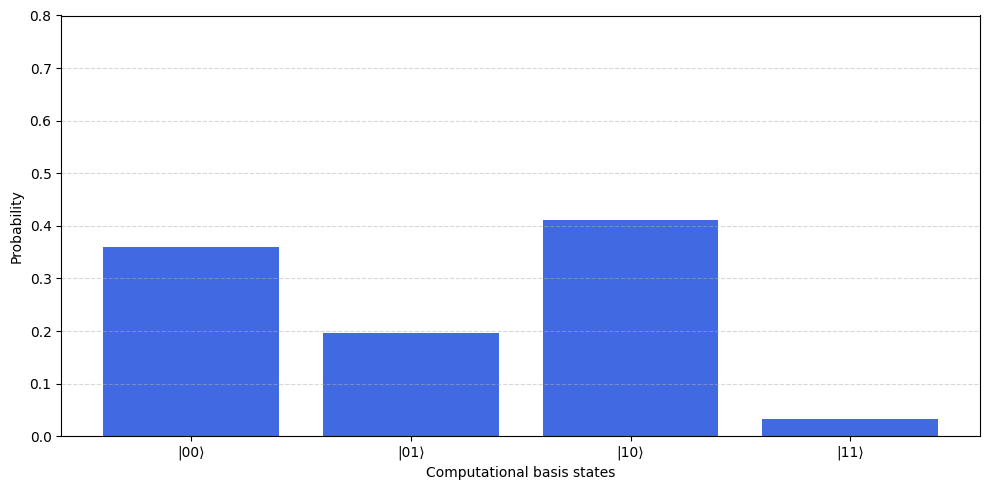

In [1219]:
plot_statevector_probabilities(evol.y[-1])

In [1237]:
np.sqrt((w7 - w8)**2 - 4J**2)/(2*np.pi)

np.complex128(0.639161424164988+0j)